# Water Segmentation Using Multispectral and Optical Data

## 1. Dataset Understanding & Exploratory Data Analysis

This notebook documents the data validation, exploratory analysis, split strategy,
channel-level statistics, and preprocessing decisions for a binary water-segmentation
task using 12-channel satellite patches.

The workflow intentionally validates the data and audits possible leakage/shortcut
features before model training.


In [61]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from PIL import Image

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Environment ready.")

Environment ready.


In [62]:
from pathlib import Path

DATASET_NAME = "/kaggle/input/datasets/nebalelshobary/satellite-multispectral-water-segmentation"

# Preferred Kaggle location for this private dataset.
DATASET_ROOT = Path(
    "/kaggle/input/datasets/nebalelshobary/satellite-multispectral-water-segmentation"
)

# Fallback: if Kaggle mounts the dataset under a slightly different root,
# locate the dataset folder by name instead of failing because of one fixed path.
if not DATASET_ROOT.exists():
    candidates = [
        p for p in Path("/kaggle/input").rglob(DATASET_NAME)
        if p.is_dir()
    ]
    if not candidates:
        raise FileNotFoundError(
            f"Could not find '{DATASET_NAME}' under /kaggle/input. "
            "Make sure the dataset is attached to this notebook."
        )
    DATASET_ROOT = candidates[0]

IMAGES_DIR = DATASET_ROOT / "images"
LABELS_DIR = DATASET_ROOT / "labels"

if not IMAGES_DIR.exists() or not LABELS_DIR.exists():
    raise FileNotFoundError(
        f"Expected 'images' and 'labels' folders inside: {DATASET_ROOT}"
    )

tif_files = sorted(IMAGES_DIR.glob("*.tif"))
png_files = sorted(LABELS_DIR.glob("*.png"))

print("Dataset root:", DATASET_ROOT)
print(f"Number of images: {len(tif_files)}")
print(f"Number of masks : {len(png_files)}")


Dataset root: /kaggle/input/datasets/nebalelshobary/satellite-multispectral-water-segmentation
Number of images: 306
Number of masks : 306


In [63]:
# Match every image with its corresponding mask using the filename ID

image_map = {p.stem: p for p in tif_files}
mask_map = {p.stem: p for p in png_files}

image_ids = set(image_map.keys())
mask_ids = set(mask_map.keys())

missing_masks = image_ids - mask_ids
missing_images = mask_ids - image_ids

print("Images without masks:", missing_masks)
print("Masks without images:", missing_images)

assert not missing_masks, "Some images do not have matching masks."
assert not missing_images, "Some masks do not have matching images."

sample_ids = sorted(image_ids, key=int)

pairs = [
    (image_map[sample_id], mask_map[sample_id])
    for sample_id in sample_ids
]

print(f"\nTotal validated pairs: {len(pairs)}")

print("\nFirst 10 pairs:")
for image_path, mask_path in pairs[:10]:
    print(f"{image_path.name} <--> {mask_path.name}")

Images without masks: set()
Masks without images: set()

Total validated pairs: 306

First 10 pairs:
0.tif <--> 0.png
1.tif <--> 1.png
2.tif <--> 2.png
3.tif <--> 3.png
4.tif <--> 4.png
5.tif <--> 5.png
6.tif <--> 6.png
7.tif <--> 7.png
8.tif <--> 8.png
9.tif <--> 9.png


In [64]:
sample_image_path, sample_mask_path = pairs[0]

with rasterio.open(sample_image_path) as src:
    sample_image = src.read()

    print("IMAGE")
    print("File        :", sample_image_path.name)
    print("Shape       :", sample_image.shape)
    print("Band count  :", src.count)
    print("Height      :", src.height)
    print("Width       :", src.width)
    print("Dtypes      :", src.dtypes)
    print("Nodata value:", src.nodata)

sample_mask = np.array(Image.open(sample_mask_path))

print("\nMASK")
print("File         :", sample_mask_path.name)
print("Shape        :", sample_mask.shape)
print("Dtype        :", sample_mask.dtype)
print("Unique values:", np.unique(sample_mask))

IMAGE
File        : 0.tif
Shape       : (12, 128, 128)
Band count  : 12
Height      : 128
Width       : 128
Dtypes      : ('int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16')
Nodata value: None

MASK
File         : 0.png
Shape        : (128, 128)
Dtype        : uint8
Unique values: [0 1]


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


### 1.1 Channel-Level Inspection

Before preprocessing, the 12 input channels are inspected numerically to understand
their ranges and semantic types. The stack contains continuous spectral bands,
terrain layers, encoded quality information, categorical land-cover information,
and a water-occurrence prior, so the channels should not automatically be treated
as identical numeric features.


In [65]:
band_names = [
    "Coastal Aerosol",
    "Blue",
    "Green",
    "Red",
    "NIR",
    "SWIR1",
    "SWIR2",
    "QA Band",
    "MERIT DEM",
    "Copernicus DEM",
    "ESA WorldCover",
    "Water Occurrence Probability"
]

sample_stats = []

for i, band_name in enumerate(band_names):
    band = sample_image[i]

    sample_stats.append({
        "Channel": i + 1,
        "Name": band_name,
        "Min": band.min(),
        "Max": band.max(),
        "Mean": band.mean(),
        "Std": band.std(),
        "Unique Values": len(np.unique(band))
    })

sample_stats_df = pd.DataFrame(sample_stats)

sample_stats_df

,Channel,Name,Min,Max,Mean,Std,Unique Values
0,1,Coastal Aerosol,14,532,174.060913,67.174908,357
1,2,Blue,-28,846,166.073486,85.886495,551
2,3,Green,-2,1099,326.943909,117.950132,724
3,4,Red,2,1297,325.766235,143.170948,806
4,5,NIR,46,4975,1945.227600,648.452807,2861
5,6,SWIR1,30,3786,1298.179260,548.285190,2511
6,7,SWIR2,16,3004,678.844910,351.285438,1724
7,8,QA Band,64,160,66.339844,8.530834,3
8,9,MERIT DEM,130,355,246.989380,39.694534,226
9,10,Copernicus DEM,172,404,291.104248,40.311342,231


## 2. Band Research: What Each Spectral Band Captures

The first seven channels are spectral measurements. The wavelength ranges below are
**approximate Landsat 8/9 OLI reference ranges** because the channel naming follows
Landsat-style bands. The supplied dataset is described as harmonized Sentinel-2/Landsat,
so the exact source/harmonization metadata should be checked before treating these
ranges as dataset-specific calibration constants.

| Channel | Band | Approx. wavelength | Expected relation to water |
|---|---|---:|---|
| 1 | Coastal Aerosol | 0.43–0.45 µm | Short visible wavelengths; can contain information about coastal/shallow water and atmospheric scattering. |
| 2 | Blue | 0.45–0.51 µm | Water can retain visible reflectance here, but blue is also sensitive to atmospheric scattering and turbidity. |
| 3 | Green | 0.53–0.59 µm | Important for water indices; water can be relatively brighter in green than in NIR/SWIR. |
| 4 | Red | 0.64–0.67 µm | Useful visible-band contrast, but dark non-water surfaces and shadows can still be confused with water. |
| 5 | NIR | 0.85–0.88 µm | Water strongly absorbs NIR, so open water often appears dark relative to vegetation and many land surfaces. |
| 6 | SWIR1 | 1.57–1.65 µm | Strong water absorption; useful for separating water from soil/built-up surfaces and for moisture-sensitive analysis. |
| 7 | SWIR2 | 2.11–2.29 µm | Also strongly absorbed by water and often provides strong water/non-water contrast. |

### Why multispectral input can outperform RGB

RGB uses only visible information. A dark pixel in RGB can be water, shadow, dark soil,
or another low-reflectance surface. NIR and SWIR add spectral information that is not
visible to the human eye and is often much more discriminative for water.

Two later engineered features will be evaluated:

\[
NDWI = \frac{Green - NIR}{Green + NIR + \epsilon}
\]

\[
MNDWI = \frac{Green - SWIR1}{Green + SWIR1 + \epsilon}
\]

These indices will be added only as explicit experiments, not assumed to improve the
model without validation.

### References supplied with the task

- U-Net: https://arxiv.org/abs/1505.04597
- Near Infrared (Esri): https://support.esri.com/en-us/gis-dictionary/near-infrared
- Multispectral segmentation paper: https://www.sciencedirect.com/science/article/abs/pii/S0924271619301522
- SWIR visualization: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/swir-rgb/
- Landsat surface-reflectance QA: https://www.usgs.gov/landsat-missions/landsat-8-9-surface-reflectance-quality-assessment


## 3. Single-Sample Visualization of the 12 Input Channels

A percentile-based contrast stretch is used **for visualization only**. It does not
modify the training data and is not the model normalization.


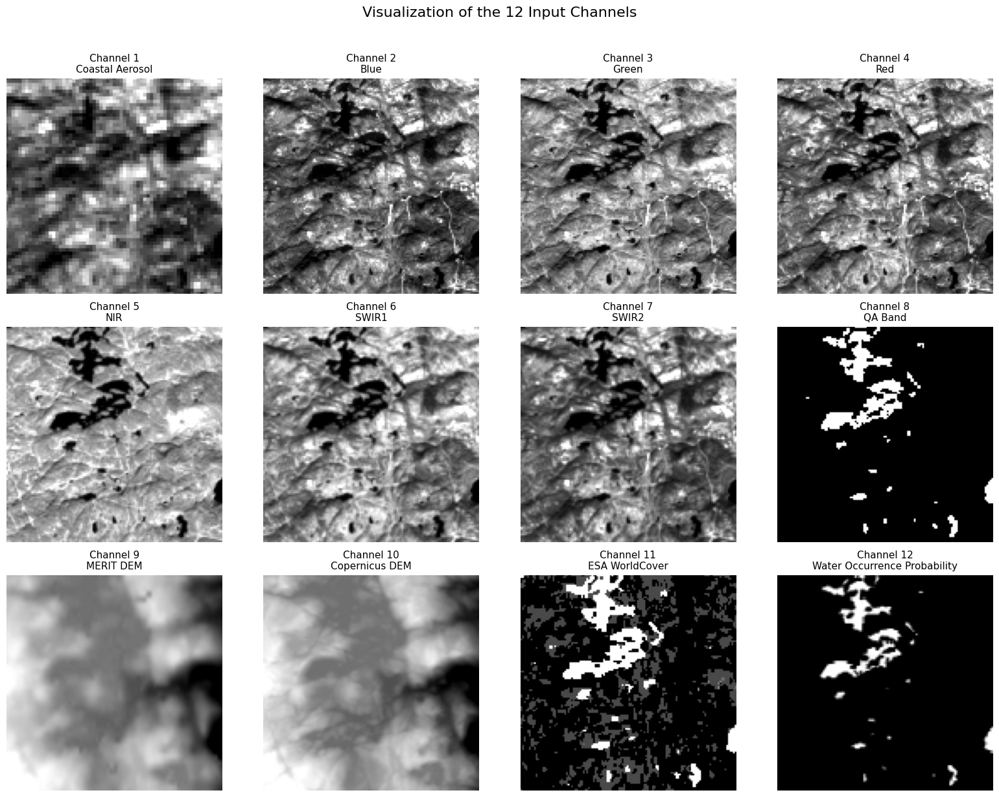

In [66]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, ax in enumerate(axes.flat):

    band = sample_image[i].astype(np.float32)

    # Contrast stretch for visualization only
    vmin = np.percentile(band, 2)
    vmax = np.percentile(band, 98)

    if vmax > vmin:
        ax.imshow(
            band,
            cmap="gray",
            vmin=vmin,
            vmax=vmax
        )
    else:
        ax.imshow(band, cmap="gray")

    ax.set_title(
        f"Channel {i + 1}\n{band_names[i]}",
        fontsize=11
    )

    ax.axis("off")

plt.suptitle(
    "Visualization of the 12 Input Channels",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

## 4. RGB Composite and Ground-Truth Mask

A natural-color RGB composite provides an intuitive visual reference. The RGB view is
compared with the binary ground-truth mask (`1 = water`, `0 = background`) to check
that the image/mask pairing is visually plausible.


In [67]:
def percentile_stretch(channel, lower=2, upper=98):

    channel = channel.astype(np.float32)

    low = np.percentile(channel, lower)
    high = np.percentile(channel, upper)

    if high <= low:
        return np.zeros_like(channel, dtype=np.float32)

    stretched = (channel - low) / (high - low)

    return np.clip(stretched, 0, 1)

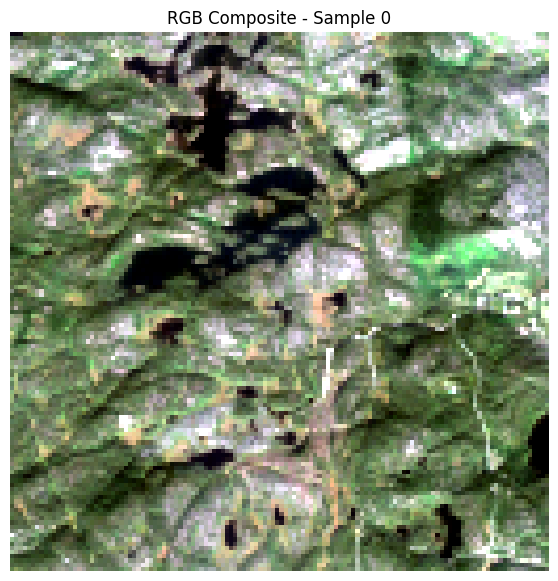

In [68]:
red = percentile_stretch(sample_image[3])
green = percentile_stretch(sample_image[2])
blue = percentile_stretch(sample_image[1])

rgb = np.stack(
    [red, green, blue],
    axis=-1
)

plt.figure(figsize=(7, 7))

plt.imshow(rgb)
plt.title("RGB Composite - Sample 0")
plt.axis("off")

plt.show()

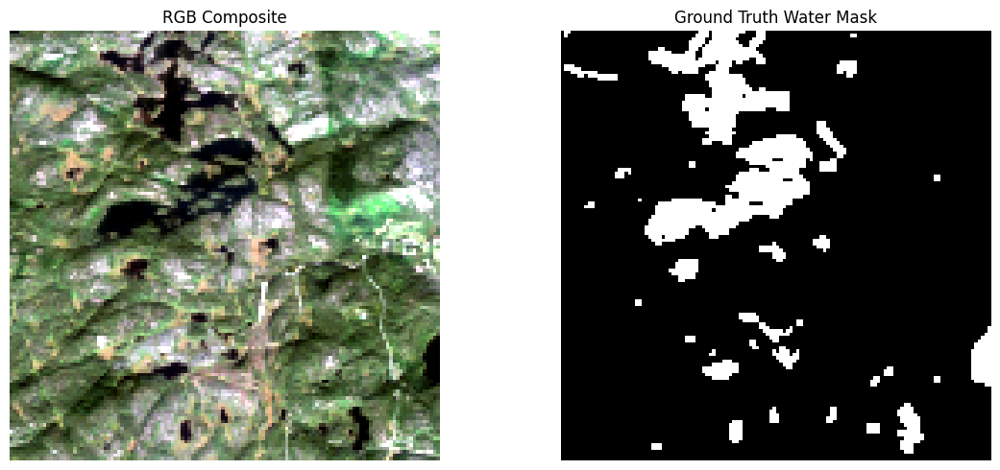

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(rgb)
axes[0].set_title("RGB Composite")
axes[0].axis("off")

axes[1].imshow(sample_mask, cmap="gray")
axes[1].set_title("Ground Truth Water Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 5. Dataset-Wide Mask Distribution

The complete set of binary masks is analyzed to quantify water/background imbalance
and to understand how water coverage varies across patches. This is important because
pixel accuracy alone can be misleading when background is the majority class.


In [70]:
mask_records = []

total_water_pixels = 0
total_background_pixels = 0

for image_path, mask_path in pairs:

    mask = np.array(Image.open(mask_path))

    water_pixels = np.sum(mask == 1)
    background_pixels = np.sum(mask == 0)
    total_pixels = mask.size

    water_percentage = (water_pixels / total_pixels) * 100

    total_water_pixels += water_pixels
    total_background_pixels += background_pixels

    mask_records.append({
        "Sample_ID": mask_path.stem,
        "Water_Pixels": water_pixels,
        "Background_Pixels": background_pixels,
        "Water_Percentage": water_percentage
    })


mask_distribution_df = pd.DataFrame(mask_records)

total_pixels_dataset = (
    total_water_pixels + total_background_pixels
)

overall_water_percentage = (
    total_water_pixels / total_pixels_dataset
) * 100

overall_background_percentage = (
    total_background_pixels / total_pixels_dataset
) * 100


print(f"Total samples              : {len(mask_distribution_df)}")
print(f"Total pixels               : {total_pixels_dataset:,}")

print(f"\nWater pixels               : {total_water_pixels:,}")
print(f"Background pixels          : {total_background_pixels:,}")

print(f"\nOverall water percentage   : {overall_water_percentage:.2f}%")
print(f"Overall background percent : {overall_background_percentage:.2f}%")

print(
    "\nMasks with no water:",
    (mask_distribution_df["Water_Pixels"] == 0).sum()
)

print(
    "Masks containing water:",
    (mask_distribution_df["Water_Pixels"] > 0).sum()
)

print(
    "Masks completely water:",
    (mask_distribution_df["Water_Percentage"] == 100).sum()
)

Total samples              : 306
Total pixels               : 5,013,504

Water pixels               : 1,302,272
Background pixels          : 3,711,232

Overall water percentage   : 25.98%
Overall background percent : 74.02%

Masks with no water: 45
Masks containing water: 261
Masks completely water: 3


In [71]:
mask_distribution_df["Water_Percentage"].describe()

count    306.000000
mean      25.975286
std       28.106650
min        0.000000
25%        1.136780
50%       16.445923
75%       42.376709
max      100.000000
Name: Water_Percentage, dtype: float64

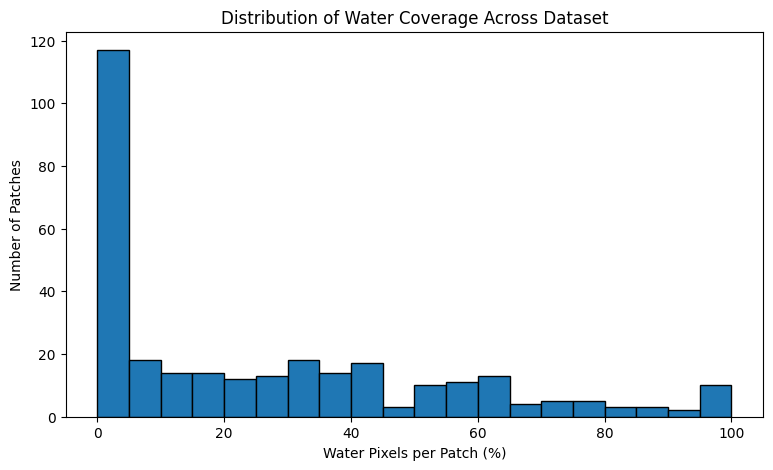

In [72]:
plt.figure(figsize=(9, 5))

plt.hist(
    mask_distribution_df["Water_Percentage"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Water Pixels per Patch (%)")
plt.ylabel("Number of Patches")
plt.title("Distribution of Water Coverage Across Dataset")

plt.show()

## 6. Representative Samples Across Water-Coverage Levels

A single sample is not sufficient to understand the dataset. The following cells select
representative patches with no water, low water, medium water, and high water coverage.

The first figure compares RGB and ground truth. A second diagnostic can display all
12 channels for representative no/low/high-water samples.


Representative samples:
No Water     -> ID   5 | water coverage = 0.00%
Low Water    -> ID 144 | water coverage = 5.09%
Medium Water -> ID 222 | water coverage = 29.65%
High Water   -> ID 293 | water coverage = 79.41%


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


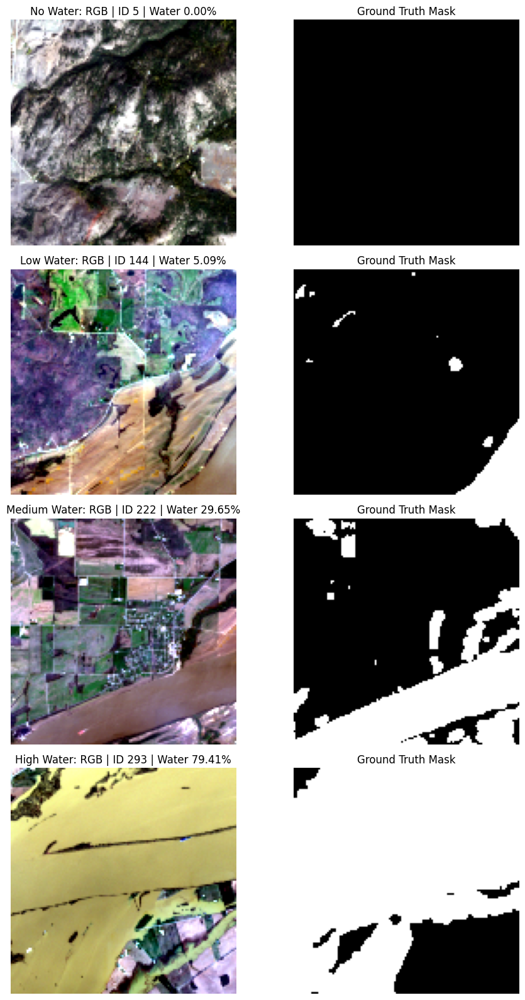

In [73]:
# Select representative samples by their ground-truth water coverage

def closest_sample_to_coverage(target_pct, df=mask_distribution_df):
    idx = (df["Water_Percentage"] - target_pct).abs().idxmin()
    row = df.loc[idx]
    return str(row["Sample_ID"]), float(row["Water_Percentage"])

representative_cases = [
    ("No Water",) + closest_sample_to_coverage(0.0),
    ("Low Water",) + closest_sample_to_coverage(5.0),
    ("Medium Water",) + closest_sample_to_coverage(30.0),
    ("High Water",) + closest_sample_to_coverage(80.0),
]

print("Representative samples:")
for label, sample_id, pct in representative_cases:
    print(f"{label:12s} -> ID {sample_id:>3s} | water coverage = {pct:.2f}%")

fig, axes = plt.subplots(len(representative_cases), 2, figsize=(10, 4 * len(representative_cases)))

for row_idx, (label, sample_id, pct) in enumerate(representative_cases):
    image_path = image_map[sample_id]
    mask_path = mask_map[sample_id]

    with rasterio.open(image_path) as src:
        image = src.read()

    mask = np.array(Image.open(mask_path))

    red = percentile_stretch(image[3])
    green = percentile_stretch(image[2])
    blue = percentile_stretch(image[1])
    rgb_rep = np.stack([red, green, blue], axis=-1)

    axes[row_idx, 0].imshow(rgb_rep)
    axes[row_idx, 0].set_title(f"{label}: RGB | ID {sample_id} | Water {pct:.2f}%")
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(mask, cmap="gray", vmin=0, vmax=1)
    axes[row_idx, 1].set_title("Ground Truth Mask")
    axes[row_idx, 1].axis("off")

plt.tight_layout()
plt.show()


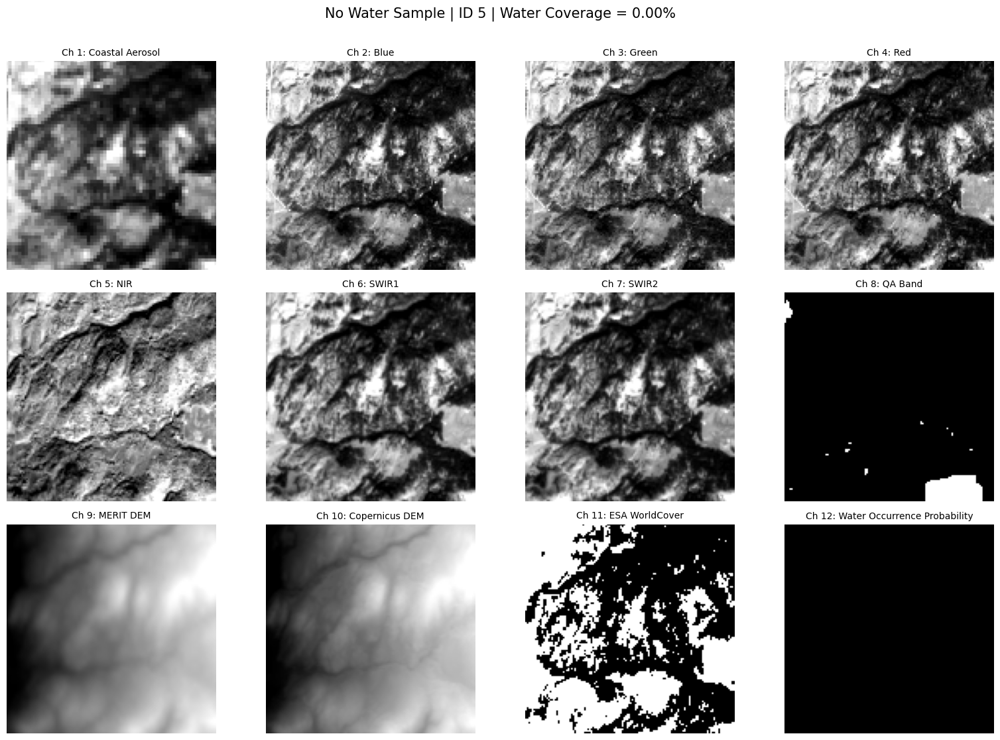

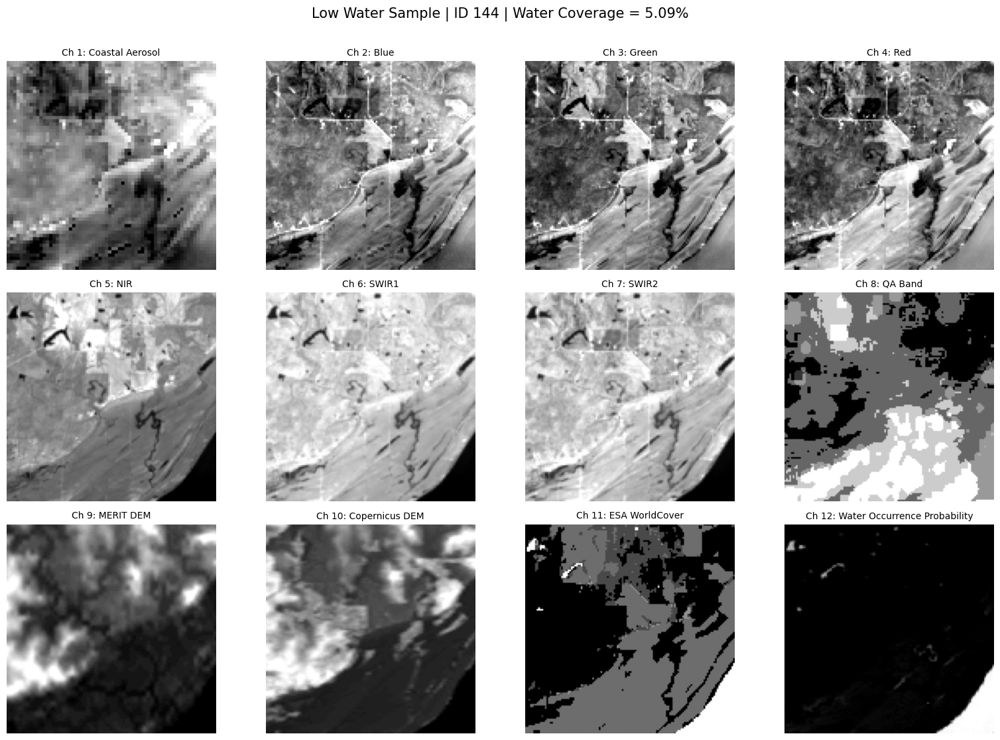

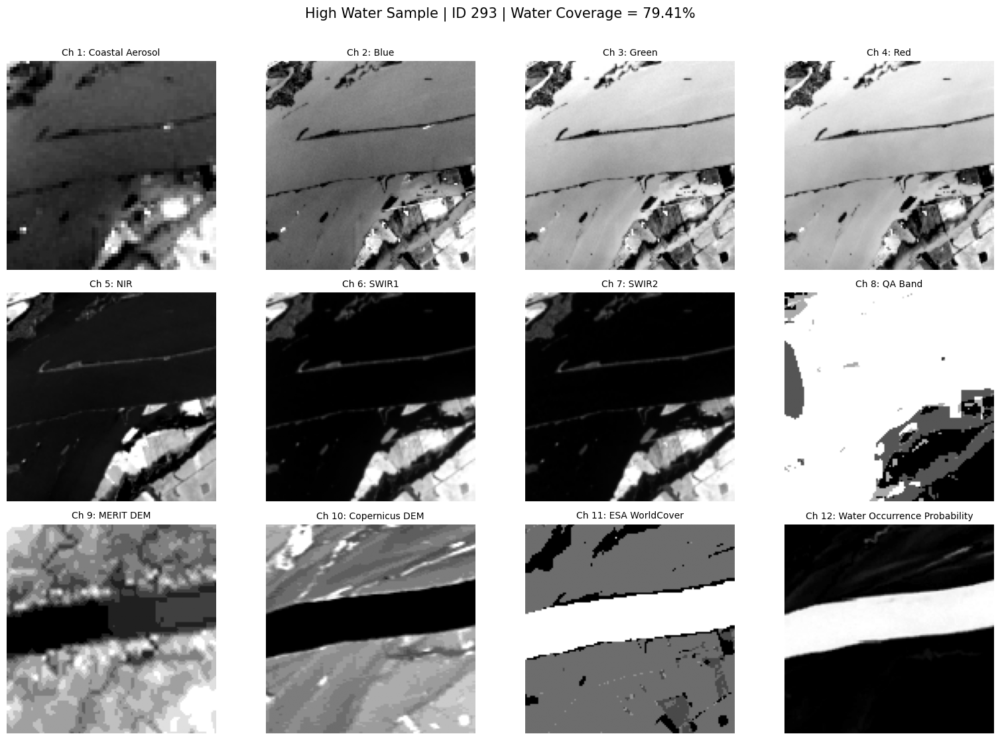

In [74]:
# Visualize all 12 channels for three representative cases:
# no-water, low-water, and high-water patches.

selected_for_all_bands = [
    representative_cases[0],
    representative_cases[1],
    representative_cases[3],
]

for label, sample_id, pct in selected_for_all_bands:
    with rasterio.open(image_map[sample_id]) as src:
        image = src.read()

    fig, axes = plt.subplots(3, 4, figsize=(16, 11))

    for i, ax in enumerate(axes.flat):
        band = image[i].astype(np.float32)
        vmin = np.percentile(band, 2)
        vmax = np.percentile(band, 98)

        if vmax > vmin:
            ax.imshow(band, cmap="gray", vmin=vmin, vmax=vmax)
        else:
            ax.imshow(band, cmap="gray")

        ax.set_title(f"Ch {i+1}: {band_names[i]}", fontsize=10)
        ax.axis("off")

    plt.suptitle(
        f"{label} Sample | ID {sample_id} | Water Coverage = {pct:.2f}%",
        fontsize=15,
        y=1.01
    )
    plt.tight_layout()
    plt.show()


## 7. Water-Coverage Groups for Stratified Splitting

Water coverage ranges from completely dry patches to fully water-covered patches.
Coverage groups are used so that the train and validation subsets preserve similar
proportions of no/low/medium/high-water samples.


In [75]:
def water_coverage_group(p):
    if p == 0:
        return "No Water"
    elif p <= 5:
        return "Very Low (0-5%)"
    elif p <= 20:
        return "Low (5-20%)"
    elif p <= 50:
        return "Medium (20-50%)"
    elif p <= 80:
        return "High (50-80%)"
    else:
        return "Very High (80-100%)"


mask_distribution_df["Coverage_Group"] = (
    mask_distribution_df["Water_Percentage"]
    .apply(water_coverage_group)
)

coverage_order = [
    "No Water",
    "Very Low (0-5%)",
    "Low (5-20%)",
    "Medium (20-50%)",
    "High (50-80%)",
    "Very High (80-100%)"
]

coverage_counts = (
    mask_distribution_df["Coverage_Group"]
    .value_counts()
    .reindex(coverage_order)
)

coverage_counts

Coverage_Group
No Water               45
Very Low (0-5%)        72
Low (5-20%)            46
Medium (20-50%)        77
High (50-80%)          48
Very High (80-100%)    18
Name: count, dtype: int64

## 8. Provisional Stratified Train–Validation Split

The current split uses water-coverage stratification (`80% train / 20% validation`).
It is **provisional** until spatial independence is checked. If multiple 128×128 patches
come from the same larger scene, adjacent tiles must not be allowed to leak across
train and validation.


In [76]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    mask_distribution_df,
    test_size=0.20,
    random_state=SEED,
    stratify=mask_distribution_df["Coverage_Group"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Training samples   : {len(train_df)}")
print(f"Validation samples : {len(val_df)}")

Training samples   : 244
Validation samples : 62


In [77]:
split_distribution = pd.DataFrame({
    "Full Dataset": mask_distribution_df["Coverage_Group"]
        .value_counts(normalize=True)
        .reindex(coverage_order) * 100,

    "Train": train_df["Coverage_Group"]
        .value_counts(normalize=True)
        .reindex(coverage_order) * 100,

    "Validation": val_df["Coverage_Group"]
        .value_counts(normalize=True)
        .reindex(coverage_order) * 100
})

split_distribution.round(2)

,Full Dataset,Train,Validation
Coverage_Group,,,
No Water,14.71,14.75,14.52
Very Low (0-5%),23.53,23.77,22.58
Low (5-20%),15.03,15.16,14.52
Medium (20-50%),25.16,25.00,25.81
High (50-80%),15.69,15.57,16.13
Very High (80-100%),5.88,5.74,6.45


In [78]:
print(
    "Train mean water coverage:",
    f"{train_df['Water_Percentage'].mean():.2f}%"
)

print(
    "Validation mean water coverage:",
    f"{val_df['Water_Percentage'].mean():.2f}%"
)

Train mean water coverage: 25.87%
Validation mean water coverage: 26.38%


## 9. Training-Set Channel Statistics

All normalization and clipping statistics are derived from the **training set only**
to avoid validation leakage. Each channel is analyzed independently across all
training images and all pixels.


In [79]:
import numpy as np
import pandas as pd
import tifffile
from tqdm.auto import tqdm

# --------------------------------------------------
# Dataset-Wide Per-Channel Statistics
# Training set only
# --------------------------------------------------

NUM_CHANNELS = 12
EXPECTED_CHW = (12, 128, 128)
EXPECTED_HWC = (128, 128, 12)

train_images = []

print(f"Loading {len(train_df)} training images...\n")

for sample_id in tqdm(
    train_df["Sample_ID"],
    desc="Loading training images"
):

    image_path = image_map[str(sample_id)]

    # Read TIFF
    image = tifffile.imread(image_path)

    # tifffile may return:
    # (128, 128, 12) = H, W, C
    # Convert it to:
    # (12, 128, 128) = C, H, W
    if image.shape == EXPECTED_HWC:
        image = np.transpose(image, (2, 0, 1))

    # Safety check
    elif image.shape != EXPECTED_CHW:
        raise ValueError(
            f"Unexpected shape for {image_path.name}: "
            f"{image.shape}"
        )

    # Convert to float32 for later calculations
    image = image.astype(np.float32)

    train_images.append(image)


# --------------------------------------------------
# Stack all training images
#
# Final shape:
# (number_of_images, channels, height, width)
# Expected:
# (244, 12, 128, 128)
# --------------------------------------------------

train_images = np.stack(train_images, axis=0)

print("\nTraining data loaded successfully.")
print("Training array shape:", train_images.shape)
print("Data type:", train_images.dtype)


# --------------------------------------------------
# Data Quality Checks
# --------------------------------------------------

nan_count_per_channel = np.isnan(
    train_images
).sum(axis=(0, 2, 3))

inf_count_per_channel = np.isinf(
    train_images
).sum(axis=(0, 2, 3))

print("\nNaN count per channel:")
print(nan_count_per_channel)

print("\nInf count per channel:")
print(inf_count_per_channel)


# --------------------------------------------------
# Dataset-Wide Per-Channel Statistics
#
# train_images shape:
# axis 0 = images
# axis 1 = channels
# axis 2 = height
# axis 3 = width
#
# We calculate across:
# images + height + width
#
# We keep channel axis separately.
# --------------------------------------------------

channel_min = train_images.min(axis=(0, 2, 3))
channel_max = train_images.max(axis=(0, 2, 3))
channel_mean = train_images.mean(axis=(0, 2, 3))
channel_std = train_images.std(axis=(0, 2, 3))


# --------------------------------------------------
# Results Table
# --------------------------------------------------

train_channel_stats = pd.DataFrame({
    "Channel": np.arange(1, NUM_CHANNELS + 1),
    "Name": band_names,
    "Train_Min": channel_min,
    "Train_Max": channel_max,
    "Train_Mean": channel_mean,
    "Train_Std": channel_std
})

print("\nDataset-Wide Per-Channel Statistics:")
display(train_channel_stats)

Loading 244 training images...



Loading training images:   0%|          | 0/244 [00:00<?, ?it/s]


Training data loaded successfully.
Training array shape: (244, 12, 128, 128)
Data type: float32

NaN count per channel:
[0 0 0 0 0 0 0 0 0 0 0 0]

Inf count per channel:
[0 0 0 0 0 0 0 0 0 0 0 0]

Dataset-Wide Per-Channel Statistics:


,Channel,Name,Train_Min,Train_Max,Train_Mean,Train_Std
0,1,Coastal Aerosol,-1393.0,6568.0,395.680450,266.247894
1,2,Blue,-1169.0,9659.0,492.083038,323.322571
2,3,Green,-722.0,11368.0,813.724548,414.071381
3,4,Red,-684.0,12041.0,964.269653,585.416260
4,5,NIR,-412.0,15841.0,2075.584961,1049.720459
5,6,SWIR1,-335.0,15252.0,1954.949463,1176.911743
6,7,SWIR2,-258.0,14647.0,1346.906860,954.377502
7,8,QA Band,64.0,255.0,102.422745,49.249424
8,9,MERIT DEM,-9999.0,4245.0,136.402344,1411.039429
9,10,Copernicus DEM,8.0,4287.0,305.066559,519.822144


In [80]:
# ============================================================
# Load Training Masks
# ============================================================

train_masks = []

for sample_id in train_df["Sample_ID"]:

    mask_path = mask_map[str(sample_id)]

    mask = np.array(
        Image.open(mask_path),
        dtype=np.uint8
    )

    if mask.shape != (128, 128):
        raise ValueError(
            f"Unexpected mask shape for {mask_path.name}: {mask.shape}"
        )

    train_masks.append(mask)

train_masks = np.stack(train_masks, axis=0)

print("Training masks shape:", train_masks.shape)
print("Unique mask values:", np.unique(train_masks))

Training masks shape: (244, 128, 128)
Unique mask values: [0 1]


## 10. Spectral Signature and Robust Range Audit

### 10.1 Water vs Background Spectral Signature

For each of the seven spectral bands, the mean and median pixel values are computed
separately for water and background pixels using **training data only**.

This directly tests how each band behaves for the target class and provides evidence
for later band selection and water-index feature engineering.


,Band,Water_Mean,Background_Mean,Water_Median,Background_Median
0,Coastal Aerosol,362.209991,407.850006,354.0,367.0
1,Blue,476.850006,497.140015,468.0,447.0
2,Green,813.239990,814.280029,817.0,746.0
3,Red,926.789978,978.409973,997.0,861.0
4,NIR,936.510010,2469.610107,601.0,2450.0
5,SWIR1,798.530029,2360.959961,291.0,2226.0
6,SWIR2,584.349976,1615.660034,297.0,1464.0


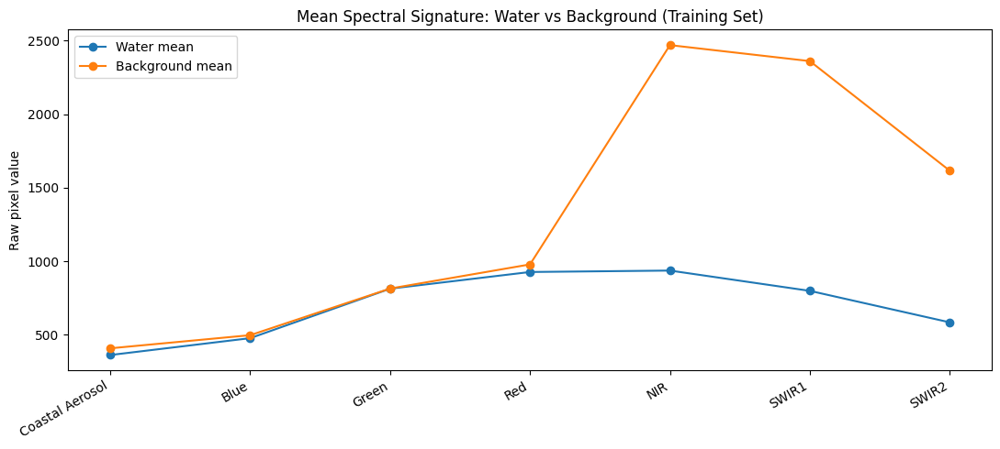

In [81]:
# Spectral signature for water vs background (training set only)

spectral_band_names = band_names[:7]
water_mask_bool = train_masks.astype(bool)

signature_records = []

for i, name in enumerate(spectral_band_names):
    band = train_images[:, i, :, :]

    water_values = band[water_mask_bool]
    background_values = band[~water_mask_bool]

    signature_records.append({
        "Band": name,
        "Water_Mean": water_values.mean(),
        "Background_Mean": background_values.mean(),
        "Water_Median": np.median(water_values),
        "Background_Median": np.median(background_values),
    })

spectral_signature_df = pd.DataFrame(signature_records)
display(spectral_signature_df.round(2))

x = np.arange(len(spectral_band_names))

plt.figure(figsize=(11, 5))
plt.plot(x, spectral_signature_df["Water_Mean"], marker="o", label="Water mean")
plt.plot(x, spectral_signature_df["Background_Mean"], marker="o", label="Background mean")
plt.xticks(x, spectral_band_names, rotation=30, ha="right")
plt.ylabel("Raw pixel value")
plt.title("Mean Spectral Signature: Water vs Background (Training Set)")
plt.legend()
plt.tight_layout()
plt.show()


### 10.2 Spectral Outlier Audit

Very large maxima should not automatically be labeled as cloud, snow, or saturation
without source documentation. Instead, the training-set tails are quantified first.

A robust preprocessing candidate is to compute clipping thresholds from the **training
set only** (for example 1st–99th percentiles) and then apply the same fixed thresholds
to both train and validation before per-band normalization.


In [82]:
# Robust percentile ranges for the seven spectral bands (training set only)

percentiles_to_check = [0.5, 1, 50, 99, 99.5]
spectral_percentile_records = []

for i, name in enumerate(spectral_band_names):
    values = train_images[:, i, :, :].reshape(-1)
    p = np.percentile(values, percentiles_to_check)

    spectral_percentile_records.append({
        "Band": name,
        "P0.5": p[0],
        "P1": p[1],
        "Median": p[2],
        "P99": p[3],
        "P99.5": p[4],
        "Raw_Min": values.min(),
        "Raw_Max": values.max(),
    })

spectral_percentiles_df = pd.DataFrame(spectral_percentile_records)
display(spectral_percentiles_df.round(2))

# Initial robust-clipping candidate to be evaluated in preprocessing experiments.
SPECTRAL_CLIP_LOW_PERCENTILE = 1.0
SPECTRAL_CLIP_HIGH_PERCENTILE = 99.0

spectral_clip_low = np.percentile(
    train_images[:, :7, :, :],
    SPECTRAL_CLIP_LOW_PERCENTILE,
    axis=(0, 2, 3)
)

spectral_clip_high = np.percentile(
    train_images[:, :7, :, :],
    SPECTRAL_CLIP_HIGH_PERCENTILE,
    axis=(0, 2, 3)
)

clip_bounds_df = pd.DataFrame({
    "Band": spectral_band_names,
    "Clip_Low_P1": spectral_clip_low,
    "Clip_High_P99": spectral_clip_high,
})

display(clip_bounds_df.round(2))


,Band,P0.5,P1,Median,P99,P99.5,Raw_Min,Raw_Max
0,Coastal Aerosol,11.0,42.0,362.0,1145.0,1832.0,-1393.0,6568.0
1,Blue,48.0,73.0,455.0,1373.0,2193.0,-1169.0,9659.0
2,Green,138.0,183.0,766.0,2003.0,2677.0,-722.0,11368.0
3,Red,-20.0,15.0,895.0,2697.0,3106.0,-684.0,12041.0
4,NIR,-68.0,-41.0,2149.0,4276.0,4600.0,-412.0,15841.0
5,SWIR1,-22.0,4.0,1975.0,4590.0,4731.0,-335.0,15252.0
6,SWIR2,-4.0,4.0,1252.0,3954.0,4107.0,-258.0,14647.0


,Band,Clip_Low_P1,Clip_High_P99
0,Coastal Aerosol,42.0,1145.0
1,Blue,73.0,1373.0
2,Green,183.0,2003.0
3,Red,15.0,2697.0
4,NIR,-41.0,4276.0
5,SWIR1,4.0,4590.0
6,SWIR2,4.0,3954.0


## 11. Auxiliary-Channel Audit

The auxiliary channels are not all continuous measurements:

- **QA Band:** encoded/bitmask-like information; exact bit meanings must be verified.
- **MERIT DEM:** continuous elevation with a suspicious `-9999` sentinel.
- **Copernicus DEM:** continuous elevation.
- **ESA WorldCover:** categorical class codes.
- **Water Occurrence:** contextual water prior with a mostly-zero distribution.

These channels are audited before deciding how to encode them.


In [83]:
# Inspect special / suspicious values in selected channels

QA_IDX = 7
MERIT_IDX = 8
WATER_OCC_IDX = 11

# 1) MERIT DEM: count -9999 values
merit = train_images[:, MERIT_IDX, :, :]

merit_nodata_count = np.sum(merit == -9999)
merit_total = merit.size

print("MERIT DEM")
print("----------------------")
print("Total pixels:", merit_total)
print("-9999 pixels:", merit_nodata_count)
print(
    "-9999 percentage:",
    f"{100 * merit_nodata_count / merit_total:.4f}%"
)


# 2) QA Band: inspect unique values and counts
qa_values, qa_counts = np.unique(
    train_images[:, QA_IDX, :, :],
    return_counts=True
)

print("\nQA Band")
print("----------------------")
print("Unique values and counts:")

for value, count in zip(qa_values.astype(int), qa_counts):
    print(f"Value {value}: {count:,} pixels")


# 3) Water Occurrence Probability: inspect values > 100
water_occ = train_images[:, WATER_OCC_IDX, :, :]

values_above_100 = water_occ[water_occ > 100]

print("\nWater Occurrence Probability")
print("----------------------")
print("Pixels > 100:", len(values_above_100))

if len(values_above_100) > 0:
    print(
        "Unique values > 100:",
        np.unique(values_above_100)
    )

    print(
        "Percentage > 100:",
        f"{100 * len(values_above_100) / water_occ.size:.4f}%"
    )

MERIT DEM
----------------------
Total pixels: 3997696
-9999 pixels: 66295
-9999 percentage: 1.6583%

QA Band
----------------------
Unique values and counts:
Value 64: 2,052,199 pixels
Value 66: 2,972 pixels
Value 68: 11,338 pixels
Value 70: 406 pixels
Value 72: 2,341 pixels
Value 74: 51 pixels
Value 76: 562 pixels
Value 78: 9 pixels
Value 80: 26,531 pixels
Value 84: 87 pixels
Value 96: 430,530 pixels
Value 100: 27 pixels
Value 112: 5,009 pixels
Value 116: 3 pixels
Value 128: 759,751 pixels
Value 130: 1,276 pixels
Value 132: 5,534 pixels
Value 134: 499 pixels
Value 136: 758 pixels
Value 138: 22 pixels
Value 140: 159 pixels
Value 142: 4 pixels
Value 144: 7,602 pixels
Value 148: 4 pixels
Value 160: 155,861 pixels
Value 164: 90 pixels
Value 176: 5,860 pixels
Value 192: 328,700 pixels
Value 194: 1,743 pixels
Value 196: 3,497 pixels
Value 198: 433 pixels
Value 200: 394 pixels
Value 202: 30 pixels
Value 204: 146 pixels
Value 206: 2 pixels
Value 208: 9,551 pixels
Value 224: 175,044 pixels
Va

In [84]:
# MERIT DEM valid-value statistics
merit = train_images[:, MERIT_IDX, :, :]

valid_merit = merit[merit != -9999]

print("Valid MERIT pixels:", valid_merit.size)
print("Valid percentage:",
      f"{100 * valid_merit.size / merit.size:.2f}%")

print("\nMERIT statistics excluding -9999")
print("--------------------------------")
print("Min :", valid_merit.min())
print("Max :", valid_merit.max())
print("Mean:", valid_merit.mean())
print("Std :", valid_merit.std())

Valid MERIT pixels: 3931401
Valid percentage: 98.34%

MERIT statistics excluding -9999
--------------------------------
Min : -1.0
Max : 4245.0
Mean: 304.6201
Std : 516.8347


In [85]:
print("MERIT valid-value distribution")
print("--------------------------------")
print("Mean   :", valid_merit.mean())
print("Median :", np.median(valid_merit))

print("\nPercentiles:")
for p in [1, 5, 25, 50, 75, 95, 99]:
    print(
        f"{p:>2}th percentile:",
        np.percentile(valid_merit, p)
    )

MERIT valid-value distribution
--------------------------------
Mean   : 304.6201
Median : 119.0

Percentiles:
 1th percentile: 16.0
 5th percentile: 21.0
25th percentile: 113.0
50th percentile: 119.0
75th percentile: 205.0
95th percentile: 1476.0
99th percentile: 2514.0


### 11.1 MERIT DEM Missing-Value Strategy

`-9999` occurs in approximately 1.66% of the MERIT DEM training pixels and strongly
distorts the raw mean/std. Excluding that sentinel gives a valid-value median of `119`,
which is a reasonable fallback imputation.

However, because a co-registered Copernicus DEM is available for the same pixels,
the preferred next step is to **validate agreement between the two DEMs** on pixels
where MERIT is valid. If the two layers are sufficiently aligned, filling missing MERIT
pixels from the corresponding Copernicus pixel preserves local terrain structure better
than a single global median.

The diagnostic below reports correlation, MAE, RMSE, and mean bias on valid MERIT
pixels. The result should be reviewed before finalizing the imputation strategy.


In [86]:
# Compare MERIT and Copernicus DEM on pixels where MERIT is valid

MERIT_IDX = 8
COPERNICUS_IDX = 9

merit = train_images[:, MERIT_IDX, :, :]
copernicus = train_images[:, COPERNICUS_IDX, :, :]

valid_dem_mask = (
    (merit != -9999) &
    np.isfinite(merit) &
    np.isfinite(copernicus)
)

merit_valid = merit[valid_dem_mask]
copernicus_valid = copernicus[valid_dem_mask]

dem_corr = np.corrcoef(merit_valid, copernicus_valid)[0, 1]
dem_diff = copernicus_valid - merit_valid
dem_mae = np.mean(np.abs(dem_diff))
dem_rmse = np.sqrt(np.mean(dem_diff ** 2))
dem_bias = np.mean(dem_diff)

print("MERIT vs Copernicus DEM (valid MERIT pixels only)")
print("--------------------------------------------------")
print(f"Valid comparison pixels : {merit_valid.size:,}")
print(f"Pearson correlation     : {dem_corr:.4f}")
print(f"MAE                     : {dem_mae:.2f}")
print(f"RMSE                    : {dem_rmse:.2f}")
print(f"Mean bias (Cop-MERIT)   : {dem_bias:.2f}")


MERIT vs Copernicus DEM (valid MERIT pixels only)
--------------------------------------------------
Valid comparison pixels : 3,931,401
Pearson correlation     : 0.9995
MAE                     : 10.02
RMSE                    : 16.90
Mean bias (Cop-MERIT)   : 3.14


In [87]:
# Candidate MERIT imputation using the co-registered Copernicus DEM.
# This does not overwrite train_images; it creates a separate candidate array.

merit_filled_from_copernicus = merit.copy()
missing_merit = merit_filled_from_copernicus == -9999

merit_filled_from_copernicus[missing_merit] = copernicus[missing_merit]

print("Missing MERIT values before:", int(missing_merit.sum()))
print(
    "Remaining -9999 values after Copernicus fill:",
    int((merit_filled_from_copernicus == -9999).sum())
)

# Optional engineered terrain feature for later ablation:
# relative elevation within each patch.
merit_relative_elevation = (
    merit_filled_from_copernicus
    - merit_filled_from_copernicus.mean(axis=(1, 2), keepdims=True)
)

print("MERIT filled shape:", merit_filled_from_copernicus.shape)
print("Relative-elevation shape:", merit_relative_elevation.shape)


Missing MERIT values before: 66295
Remaining -9999 values after Copernicus fill: 0
MERIT filled shape: (244, 128, 128)
Relative-elevation shape: (244, 128, 128)


### 11.2 QA Band and Water Occurrence Inspection

The QA channel is treated as encoded information. No bit is assigned a semantic label
(e.g. clear/cloud/water) until the **dataset-specific QA documentation** is confirmed.

The Water Occurrence layer is a strong contextual prior and may create shortcut learning.
Values above 100 are extremely rare. Following the instructor's recommendation, a
`[0, 100]` clipped version is prepared as a preprocessing candidate, while the original
distribution is retained for audit.


In [88]:
# ============================================================
# QA Band & Water Occurrence Detailed Inspection
# ============================================================

QA_IDX = 7
WATER_OCC_IDX = 11

# ------------------------------------------------------------
# 1. QA Band distribution
# ------------------------------------------------------------

qa = train_images[:, QA_IDX, :, :]

qa_values, qa_counts = np.unique(
    qa,
    return_counts=True
)

qa_percentages = (
    qa_counts / qa.size
) * 100

qa_distribution_df = pd.DataFrame({
    "QA_Value": qa_values.astype(int),
    "Pixel_Count": qa_counts,
    "Percentage": qa_percentages
})

qa_distribution_df = (
    qa_distribution_df
    .sort_values("Pixel_Count", ascending=False)
    .reset_index(drop=True)
)

print("QA BAND DISTRIBUTION")
print("--------------------")
print("Number of unique QA values:", len(qa_values))

display(
    qa_distribution_df.style.format({
        "Percentage": "{:.4f}%"
    })
)


# ------------------------------------------------------------
# 2. Water Occurrence distribution
# ------------------------------------------------------------

water_occ = train_images[:, WATER_OCC_IDX, :, :]

print("\nWATER OCCURRENCE DISTRIBUTION")
print("-----------------------------")

print("Min   :", water_occ.min())
print("Max   :", water_occ.max())
print("Mean  :", water_occ.mean())
print("Median:", np.median(water_occ))
print("Std   :", water_occ.std())

print("\nPercentiles:")

for p in [1, 5, 25, 50, 75, 90, 95, 99, 99.9]:
    print(
        f"{p}th percentile:",
        np.percentile(water_occ, p)
    )


# ------------------------------------------------------------
# 3. Values greater than 100
# ------------------------------------------------------------

above_100 = water_occ[water_occ > 100]

print("\nVALUES ABOVE 100")
print("----------------")

print("Total pixels > 100:", len(above_100))

if len(above_100) > 0:

    values, counts = np.unique(
        above_100,
        return_counts=True
    )

    above_100_df = pd.DataFrame({
        "Value": values.astype(int),
        "Count": counts
    })

    above_100_df["Percentage_of_All_Pixels"] = (
        above_100_df["Count"] / water_occ.size
    ) * 100

    display(
        above_100_df.style.format({
            "Percentage_of_All_Pixels": "{:.6f}%"
        })
    )

QA BAND DISTRIBUTION
--------------------
Number of unique QA values: 41


,QA_Value,Pixel_Count,Percentage
0,64,2052199,51.3345%
1,128,759751,19.0047%
2,96,430530,10.7695%
3,192,328700,8.2222%
4,224,175044,4.3786%
5,160,155861,3.8988%
6,80,26531,0.6637%
7,68,11338,0.2836%
8,208,9551,0.2389%
9,240,8573,0.2144%



WATER OCCURRENCE DISTRIBUTION
-----------------------------
Min   : 0.0
Max   : 111.0
Mean  : 10.28859
Median: 0.0
Std   : 28.448011

Percentiles:
1th percentile: 0.0
5th percentile: 0.0
25th percentile: 0.0
50th percentile: 0.0
75th percentile: 0.0
90th percentile: 70.0
95th percentile: 94.0
99th percentile: 99.0
99.9th percentile: 99.0

VALUES ABOVE 100
----------------
Total pixels > 100: 191


,Value,Count,Percentage_of_All_Pixels
0,101,76,0.001901%
1,102,31,0.000775%
2,103,14,0.000350%
3,104,51,0.001276%
4,105,17,0.000425%
5,107,1,0.000025%
6,111,1,0.000025%


In [89]:
# Water Occurrence clipping candidate

WATER_OCC_IDX = 11
water_occ = train_images[:, WATER_OCC_IDX, :, :]

water_occ_clipped = np.clip(water_occ, 0, 100)

changed_pixels = int(np.sum(water_occ_clipped != water_occ))

print("Pixels changed by clipping to [0, 100]:", changed_pixels)
print("Original min/max:", float(water_occ.min()), float(water_occ.max()))
print(
    "Clipped min/max:",
    float(water_occ_clipped.min()),
    float(water_occ_clipped.max())
)


Pixels changed by clipping to [0, 100]: 191
Original min/max: 0.0 111.0
Clipped min/max: 0.0 100.0


### 11.3 QA Bit-Level Leakage Audit

The QA integer is decoded into eight binary bits **for analysis only**. No bit is assigned
a semantic meaning until the dataset-specific QA encoding is confirmed.

For each bit, the notebook measures how frequently it is active and how strongly it is
associated with the ground-truth water mask. A very strong association is treated as a
potential shortcut signal rather than automatically as a legitimate predictive feature.

This keeps the QA analysis in one place instead of duplicating it in a separate section.


In [90]:
# ============================================================
# QA Bit-Level Exploration
# ============================================================

QA_IDX = 7

qa = train_images[:, QA_IDX, :, :].astype(np.uint16)

qa_bit_records = []

for bit in range(8):
    bit_mask = (qa >> bit) & 1

    active_pixels = int(bit_mask.sum())
    active_percentage = 100 * active_pixels / bit_mask.size

    if active_pixels > 0:
        water_percentage_when_active = (
            train_masks[bit_mask == 1].mean() * 100
        )
    else:
        water_percentage_when_active = np.nan

    qa_bit_records.append({
        "Bit": bit,
        "Active_Pixels": active_pixels,
        "Active_Percentage": active_percentage,
        "Water_Percentage_When_Active": water_percentage_when_active
    })

qa_bits_df = pd.DataFrame(qa_bit_records)

# Use a plain DataFrame rather than a Styler so the values remain visible
# when the notebook is shared/exported.
qa_bits_display = qa_bits_df.copy()
qa_bits_display["Active_Percentage"] = qa_bits_display["Active_Percentage"].round(2)
qa_bits_display["Water_Percentage_When_Active"] = (
    qa_bits_display["Water_Percentage_When_Active"].round(2)
)

display(qa_bits_display)


,Bit,Active_Pixels,Active_Percentage,Water_Percentage_When_Active
0,0,62,0.00,100.00
1,1,7509,0.19,7.67
2,2,22898,0.57,8.74
3,3,4540,0.11,3.85
4,4,63285,1.58,49.15
5,5,781095,19.54,91.81
6,6,3060276,76.55,26.16
7,7,1465631,36.66,30.75


In [91]:
# Quantify how strong QA bit 5 is if it is used by itself as a water classifier.
# This is a diagnostic only; it is NOT a model baseline.

QA_SHORTCUT_BIT = 5

qa_bit5_pred = ((qa >> QA_SHORTCUT_BIT) & 1).astype(np.uint8)
qa_target = train_masks.astype(np.uint8)

tp = int(np.sum((qa_bit5_pred == 1) & (qa_target == 1)))
fp = int(np.sum((qa_bit5_pred == 1) & (qa_target == 0)))
fn = int(np.sum((qa_bit5_pred == 0) & (qa_target == 1)))
tn = int(np.sum((qa_bit5_pred == 0) & (qa_target == 0)))

precision = tp / (tp + fp) if (tp + fp) else 0.0
recall = tp / (tp + fn) if (tp + fn) else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
iou = tp / (tp + fp + fn) if (tp + fp + fn) else 0.0

print(f"QA bit {QA_SHORTCUT_BIT} as a stand-alone water rule")
print("------------------------------------------------")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"IoU       : {iou:.4f}")
print(f"TP / FP / FN / TN: {tp:,} / {fp:,} / {fn:,} / {tn:,}")


QA bit 5 as a stand-alone water rule
------------------------------------------------
Precision : 0.9181
Recall    : 0.6934
F1-score  : 0.7901
IoU       : 0.6530
TP / FP / FN / TN: 717,161 / 63,934 / 317,151 / 2,899,450


**Interpretation.** If one QA bit alone reaches a strong F1/IoU, that is evidence that QA
can provide a shortcut to the target. Therefore QA is excluded from the clean spectral
baseline and is added only in the final ablation experiment. Its semantic meaning must
still be verified from dataset-specific documentation before any physical interpretation.


## 12. ESA WorldCover: Categorical Representation

ESA WorldCover contains class codes rather than continuous measurements. Therefore,
standardizing the raw numeric codes would incorrectly impose an ordinal relationship
between classes.

The training set is first audited for unique codes. A one-hot representation is then
defined for later model experiments. The raw code version may still be kept only as a
naive benchmark, not as the preferred final representation.


In [92]:
# ============================================================
# ESA WorldCover Distribution
# ============================================================

WORLDCOVER_IDX = 10

worldcover = train_images[:, WORLDCOVER_IDX, :, :]

wc_values, wc_counts = np.unique(
    worldcover,
    return_counts=True
)

wc_percentages = (
    wc_counts / worldcover.size
) * 100

worldcover_df = pd.DataFrame({
    "WorldCover_Code": wc_values.astype(int),
    "Pixel_Count": wc_counts,
    "Percentage": wc_percentages
})

worldcover_df = (
    worldcover_df
    .sort_values("Pixel_Count", ascending=False)
    .reset_index(drop=True)
)

print("ESA WORLDCOVER DISTRIBUTION")
print("---------------------------")
print("Number of unique codes:", len(wc_values))

display(
    worldcover_df.style.format({
        "Percentage": "{:.4f}%"
    })
)

ESA WORLDCOVER DISTRIBUTION
---------------------------
Number of unique codes: 10


,WorldCover_Code,Pixel_Count,Percentage
0,40,1461261,36.5526%
1,10,941134,23.5419%
2,30,915966,22.9123%
3,80,450478,11.2684%
4,50,103375,2.5859%
5,60,60155,1.5047%
6,20,52226,1.3064%
7,90,10185,0.2548%
8,100,2890,0.0723%
9,70,26,0.0007%


In [93]:
# Prepare a reusable one-hot encoder for ESA WorldCover.
# The code set is learned from the training set only.

WORLD_COVER_CODES = np.sort(wc_values.astype(np.int32))

def one_hot_worldcover(worldcover_layer, codes=WORLD_COVER_CODES):
    """
    worldcover_layer: 2D array (H, W)
    returns: float32 array (num_classes, H, W)
    """
    return np.stack(
        [(worldcover_layer == code) for code in codes],
        axis=0
    ).astype(np.float32)

worldcover_demo = one_hot_worldcover(worldcover[0])

print("WorldCover codes:", WORLD_COVER_CODES)
print("One-hot demo shape:", worldcover_demo.shape)
print(
    "Every pixel assigned to exactly one class:",
    bool(np.all(worldcover_demo.sum(axis=0) == 1))
)


WorldCover codes: [ 10  20  30  40  50  60  70  80  90 100]
One-hot demo shape: (10, 128, 128)
Every pixel assigned to exactly one class: True


### 12.1 Auxiliary Shortcut-Strength Audit

QA, Water Occurrence, and ESA WorldCover can encode information that is already strongly related to the water label. To quantify this risk before model training, each auxiliary source is tested as a **stand-alone binary rule** on the training set:

- **QA bit 5 = 1**
- **Water Occurrence > 50**
- **ESA WorldCover class = 80**

These are **diagnostic rules only**, not model baselines and not final decision thresholds. Their purpose is to measure how much target information each auxiliary channel can provide by itself. Strong F1/IoU from a single rule would indicate shortcut risk and motivates the E0–E5 ablation design.

In [94]:
# ============================================================
# 12.1 Auxiliary Shortcut-Strength Audit
# ============================================================


def binary_rule_metrics(pred, target, rule_name):
    pred = np.asarray(pred, dtype=np.uint8)
    target = np.asarray(target, dtype=np.uint8)

    tp = int(np.sum((pred == 1) & (target == 1)))
    fp = int(np.sum((pred == 1) & (target == 0)))
    fn = int(np.sum((pred == 0) & (target == 1)))
    tn = int(np.sum((pred == 0) & (target == 0)))

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall)
        else 0.0
    )
    iou = tp / (tp + fp + fn) if (tp + fp + fn) else 0.0
    predicted_positive_rate = pred.mean()

    return {
        "Rule": rule_name,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "IoU": iou,
        "Predicted_Positive_Rate": predicted_positive_rate,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
    }


shortcut_target = train_masks.astype(np.uint8)

# 1) QA bit 5
qa_uint16 = train_images[:, QA_IDX, :, :].astype(np.uint16)
qa_bit5_rule = ((qa_uint16 >> 5) & 1).astype(np.uint8)

# 2) Water Occurrence > 50
water_occ_rule = (
    train_images[:, WATER_OCC_IDX, :, :] > 50
).astype(np.uint8)

# 3) ESA WorldCover class 80
worldcover_rule = (
    train_images[:, WORLDCOVER_IDX, :, :].astype(np.int32) == 80
).astype(np.uint8)

shortcut_strength_df = pd.DataFrame([
    binary_rule_metrics(qa_bit5_rule, shortcut_target, "QA bit 5 = 1"),
    binary_rule_metrics(water_occ_rule, shortcut_target, "Water Occurrence > 50"),
    binary_rule_metrics(worldcover_rule, shortcut_target, "WorldCover class 80"),
])

metric_cols = [
    "Precision",
    "Recall",
    "F1",
    "IoU",
    "Predicted_Positive_Rate",
]
shortcut_strength_df[metric_cols] = (
    shortcut_strength_df[metric_cols].round(4)
)

print("Stand-alone auxiliary shortcut strength (training set only)")
print("----------------------------------------------------------")
display(shortcut_strength_df)

print("\nInterpretation:")
print("- Higher stand-alone F1/IoU means stronger shortcut potential.")
print("- These rules are diagnostics only and are not used as segmentation models.")
print("- QA remains excluded from the clean baseline and is added only in the final ablation.")

Stand-alone auxiliary shortcut strength (training set only)
----------------------------------------------------------


,Rule,Precision,Recall,F1,IoU,Predicted_Positive_Rate,TP,FP,FN,TN
0,QA bit 5 = 1,0.9181,0.6934,0.7901,0.6530,0.1954,717161,63934,317151,2899450
1,Water Occurrence > 50,0.9928,0.3994,0.5696,0.3982,0.1041,413089,2988,621223,2960396
2,WorldCover class 80,0.9938,0.4328,0.6030,0.4317,0.1127,447676,2802,586636,2960582



Interpretation:
- Higher stand-alone F1/IoU means stronger shortcut potential.
- These rules are diagnostics only and are not used as segmentation models.
- QA remains excluded from the clean baseline and is added only in the final ablation.


**Decision.** The clean baseline remains free of QA. Water Occurrence and WorldCover are treated as auxiliary features whose contribution must be measured through ablation rather than assumed. The shortcut-strength table should be reported alongside the ablation results and summarized in the README.

## 13. Revised Preprocessing and Ablation Plan

The final feature set will not be chosen by assumption. The experiments should change
one feature group at a time while keeping the split, architecture, loss, optimizer,
learning rate, epochs, augmentations, random seed, and evaluation threshold fixed.

| Experiment | Input feature group | Purpose |
|---|---|---|
| E0 | Spectral bands only (1–7) | Clean physics-based baseline without auxiliary shortcuts |
| E1 | E0 + engineered water indices (e.g. NDWI, MNDWI) | Test explicit water-sensitive features |
| E2 | E1 + DEM features | Test terrain context; include validated MERIT/Copernicus handling |
| E3 | E2 + WorldCover one-hot | Test categorical land-cover context |
| E4 | E3 + Water Occurrence (clipped 0–100) | Quantify gain from the strong historical water prior |
| E5 | E4 + decoded QA bits | Quantify QA contribution and shortcut/leakage risk |

A separate task-required **12-channel U-Net benchmark** can still be trained for direct
comparison, but it should not be assumed to be the final model.

### Important leakage rule

If the dataset owner confirms that multiple 128×128 patches come from the same larger
scene, the train/validation split must be rebuilt using scene/group IDs before any model
comparison is considered trustworthy.

### Reproducibility note

When PyTorch is introduced, add `torch.manual_seed(SEED)` and the corresponding CUDA
seed settings before model construction/training.


## 14. Spatial Leakage Diagnostic

The current train/validation split is stratified by water coverage, but this does
not guarantee spatial independence.

A first hypothesis tests whether every 16 consecutive 128×128 samples could represent
a 4×4 subdivision of a 512×512 parent scene. The sequential mosaics are inspected
visually, but this hypothesis is not treated as proof because sample IDs may have been
shuffled.

A second, dataset-wide **edge-matching** diagnostic compares right↔left and bottom↔top
spectral boundary profiles across all patch pairs. If true neighboring patches are
present in the dataset, unusually low edge errors may reveal candidate spatial neighbors.

Both checks are heuristics. The split is changed only if source-scene metadata or strong,
repeatable spatial evidence supports a grouping.


In [95]:
# ============================================================
# 14.1 Inspect Numeric Sample IDs
# ============================================================

numeric_ids = sorted(
    [int(sample_id) for sample_id in image_map.keys()]
)

print("Number of numeric IDs:", len(numeric_ids))
print("Minimum ID:", min(numeric_ids))
print("Maximum ID:", max(numeric_ids))

expected_ids = set(range(min(numeric_ids), max(numeric_ids) + 1))
actual_ids = set(numeric_ids)

missing_numeric_ids = sorted(expected_ids - actual_ids)

print("Missing IDs:", missing_numeric_ids[:20])
print("Number of missing IDs:", len(missing_numeric_ids))

print("\nFirst 32 IDs:")
print(numeric_ids[:32])


Number of numeric IDs: 306
Minimum ID: 0
Maximum ID: 305
Missing IDs: []
Number of missing IDs: 0

First 32 IDs:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]


In [96]:
# ============================================================
# 14.2 Candidate 512x512 Scene Group Audit
# ============================================================

# Hypothesis only:
# 512 / 128 = 4 patches per side
# 4 x 4 = 16 patches per possible larger scene

PATCHES_PER_SCENE = 16

split_audit_df = mask_distribution_df.copy()

split_audit_df["Sample_ID_Int"] = (
    split_audit_df["Sample_ID"].astype(int)
)

# Candidate scene group under the sequential-ID hypothesis
split_audit_df["Candidate_Scene_ID"] = (
    split_audit_df["Sample_ID_Int"] // PATCHES_PER_SCENE
)

train_ids = set(train_df["Sample_ID"].astype(str))
val_ids = set(val_df["Sample_ID"].astype(str))

split_audit_df["Split"] = np.where(
    split_audit_df["Sample_ID"].astype(str).isin(train_ids),
    "Train",
    "Validation"
)

candidate_scene_summary = (
    split_audit_df
    .groupby("Candidate_Scene_ID")["Split"]
    .agg(
        Total_Patches="count",
        Train_Patches=lambda x: (x == "Train").sum(),
        Validation_Patches=lambda x: (x == "Validation").sum()
    )
    .reset_index()
)

candidate_scene_summary["Split_Across_Train_Val"] = (
    (candidate_scene_summary["Train_Patches"] > 0)
    &
    (candidate_scene_summary["Validation_Patches"] > 0)
)

display(candidate_scene_summary)

num_candidate_scenes = len(candidate_scene_summary)

num_mixed_candidate_scenes = int(
    candidate_scene_summary["Split_Across_Train_Val"].sum()
)

print("Candidate scene groups:", num_candidate_scenes)
print(
    "Candidate groups appearing in BOTH Train and Validation:",
    num_mixed_candidate_scenes
)

print(
    "Percentage mixed:",
    f"{100 * num_mixed_candidate_scenes / num_candidate_scenes:.2f}%"
)


,Candidate_Scene_ID,Total_Patches,Train_Patches,Validation_Patches,Split_Across_Train_Val
0,0,16,13,3,True
1,1,16,15,1,True
2,2,16,11,5,True
3,3,16,10,6,True
4,4,16,9,7,True
5,5,16,13,3,True
6,6,16,16,0,False
7,7,16,11,5,True
8,8,16,12,4,True
9,9,16,15,1,True


Candidate scene groups: 20
Candidate groups appearing in BOTH Train and Validation: 18
Percentage mixed: 90.00%


In [97]:
# ============================================================
# 14.3 Candidate 4x4 RGB Mosaic
# ============================================================

def read_multispectral_image(sample_id):
    image_path = image_map[str(sample_id)]

    with rasterio.open(image_path) as src:
        image = src.read().astype(np.float32)

    return image


def make_rgb_for_display(image):
    """
    Convert a 12-channel image to an RGB visualization.

    Band indices:
    Red   = 3
    Green = 2
    Blue  = 1
    """

    def stretch(channel):
        low = np.percentile(channel, 2)
        high = np.percentile(channel, 98)

        if high <= low:
            return np.zeros_like(channel, dtype=np.float32)

        channel = (channel - low) / (high - low)

        return np.clip(channel, 0, 1)

    red = stretch(image[3])
    green = stretch(image[2])
    blue = stretch(image[1])

    rgb = np.stack(
        [red, green, blue],
        axis=-1
    )

    return rgb


In [98]:
def visualize_candidate_scene(candidate_scene_id):

    start_id = candidate_scene_id * PATCHES_PER_SCENE

    candidate_ids = list(
        range(start_id, start_id + PATCHES_PER_SCENE)
    )

    available_ids = [
        sample_id
        for sample_id in candidate_ids
        if str(sample_id) in image_map
    ]

    if len(available_ids) != PATCHES_PER_SCENE:
        print(
            f"Candidate scene {candidate_scene_id}: "
            f"only {len(available_ids)}/16 patches available."
        )
        return

    fig, axes = plt.subplots(
        4,
        4,
        figsize=(12, 12)
    )

    for position, sample_id in enumerate(candidate_ids):

        row = position // 4
        col = position % 4

        image = read_multispectral_image(sample_id)
        rgb = make_rgb_for_display(image)

        split_name = (
            "Train"
            if str(sample_id) in train_ids
            else "Validation"
        )

        axes[row, col].imshow(rgb)

        axes[row, col].set_title(
            f"ID {sample_id} | {split_name}",
            fontsize=9
        )

        axes[row, col].axis("off")

    plt.suptitle(
        f"Candidate 4×4 Scene - IDs {start_id} to {start_id + 15}",
        fontsize=15
    )

    plt.tight_layout()
    plt.show()


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


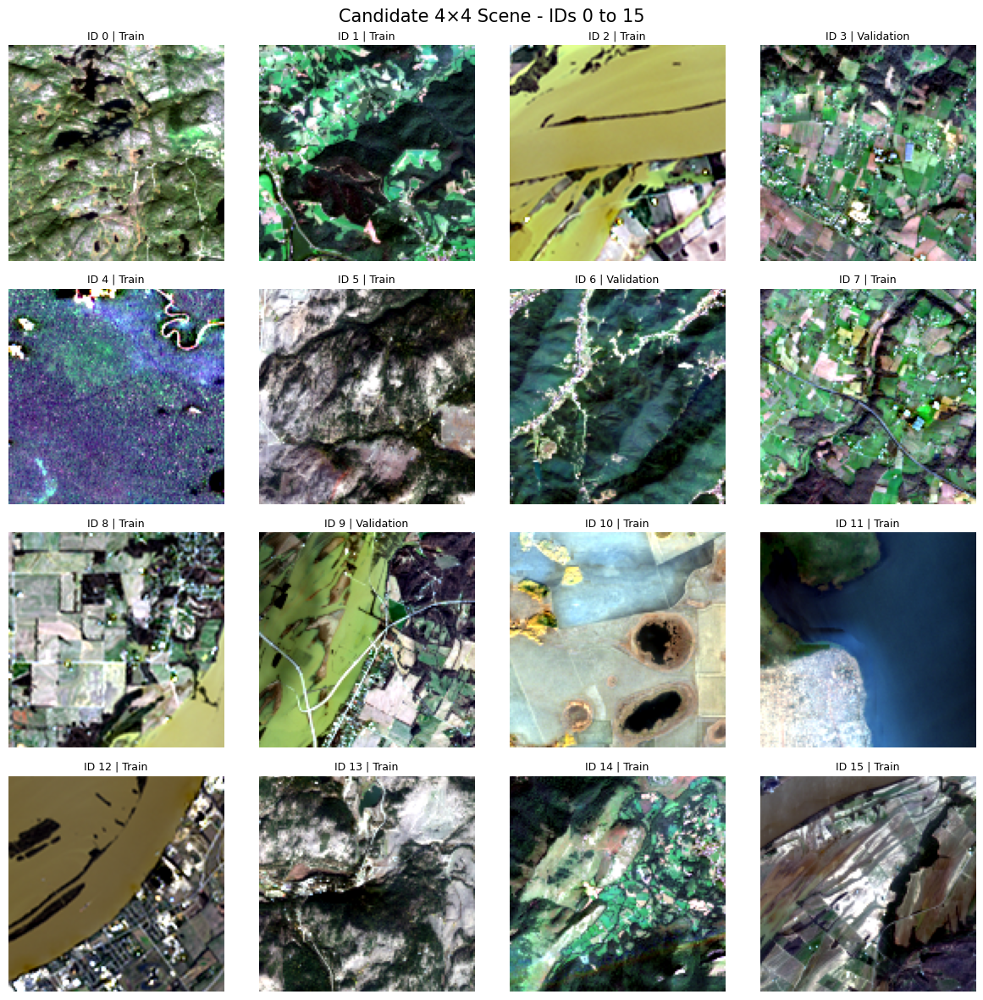

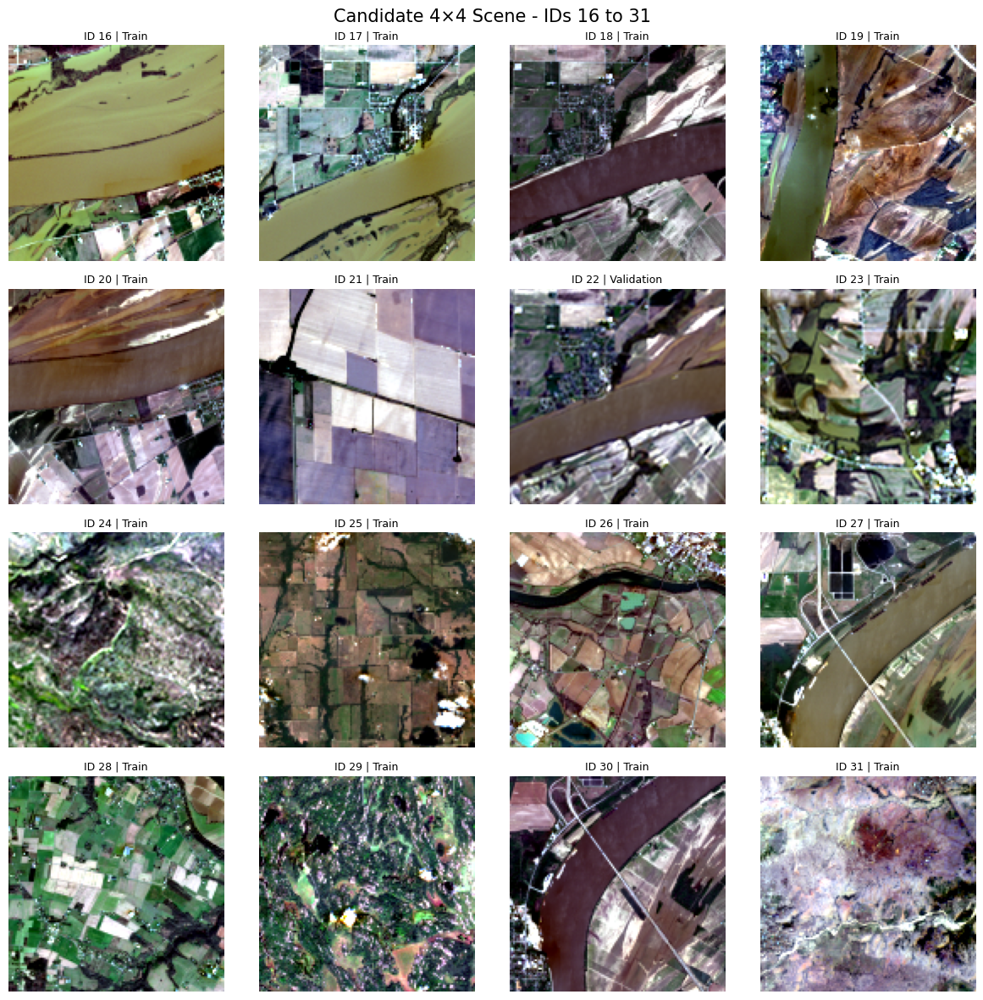

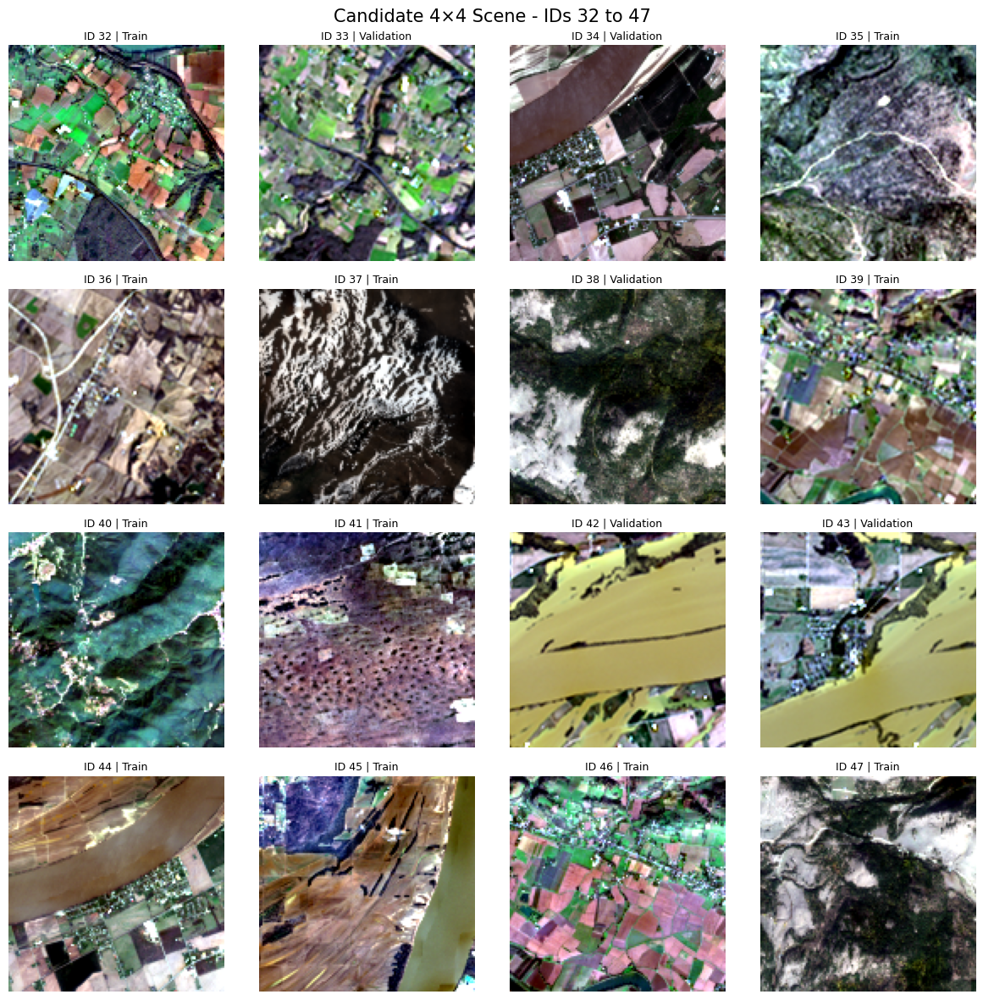

In [99]:
for candidate_scene_id in [0, 1, 2]:
    visualize_candidate_scene(candidate_scene_id)


### 14.4 Dataset-Wide Edge Matching

The sequential-ID mosaic tests only one possible ordering. To test for shuffled spatial
neighbors, this diagnostic compares patch boundaries across the full dataset.

For each patch, the first seven spectral bands are clipped and scaled using the
**training-derived P1–P99 bounds**. A narrow edge strip is averaged into a spectral
boundary profile. The following two directions are compared for every pair of different
patches:

- right edge of patch A ↔ left edge of patch B,
- bottom edge of patch A ↔ top edge of patch B.

The score is RMSE across the normalized multi-band edge profile. Lower scores indicate
more similar boundaries, but similarity alone does **not** prove geographic adjacency.
The best candidates must be inspected visually, because similar land cover can produce
false matches.


In [100]:
# ============================================================
# 14.4a Build normalized spectral edge profiles for all patches
# ============================================================

from sklearn.metrics import pairwise_distances

EDGE_STRIP_WIDTH = 4

clip_low = spectral_clip_low.astype(np.float32)
clip_high = spectral_clip_high.astype(np.float32)
clip_range = np.maximum(clip_high - clip_low, 1e-6)

edge_records = []

for sample_id in sample_ids:
    with rasterio.open(image_map[str(sample_id)]) as src:
        image = src.read().astype(np.float32)

    spectral = image[:7]

    # Use training-derived clipping bounds for every sample.
    spectral = np.clip(
        spectral,
        clip_low[:, None, None],
        clip_high[:, None, None]
    )
    spectral = (
        spectral - clip_low[:, None, None]
    ) / clip_range[:, None, None]

    # Average a narrow strip so the comparison is less sensitive to one noisy column/row.
    left_profile = spectral[:, :, :EDGE_STRIP_WIDTH].mean(axis=2)
    right_profile = spectral[:, :, -EDGE_STRIP_WIDTH:].mean(axis=2)
    top_profile = spectral[:, :EDGE_STRIP_WIDTH, :].mean(axis=1)
    bottom_profile = spectral[:, -EDGE_STRIP_WIDTH:, :].mean(axis=1)

    edge_records.append({
        "Sample_ID": str(sample_id),
        "Left": left_profile.reshape(-1),
        "Right": right_profile.reshape(-1),
        "Top": top_profile.reshape(-1),
        "Bottom": bottom_profile.reshape(-1),
    })

edge_ids = [record["Sample_ID"] for record in edge_records]

left_features = np.stack([record["Left"] for record in edge_records]).astype(np.float32)
right_features = np.stack([record["Right"] for record in edge_records]).astype(np.float32)
top_features = np.stack([record["Top"] for record in edge_records]).astype(np.float32)
bottom_features = np.stack([record["Bottom"] for record in edge_records]).astype(np.float32)

print("Patches analyzed:", len(edge_ids))
print("Edge feature length:", left_features.shape[1])


Patches analyzed: 306
Edge feature length: 896


In [101]:
# ============================================================
# 14.4b Rank the best right-left and bottom-top candidate matches
# ============================================================

feature_dim = left_features.shape[1]

right_left_rmse = (
    pairwise_distances(right_features, left_features, metric="euclidean")
    / np.sqrt(feature_dim)
)

bottom_top_rmse = (
    pairwise_distances(bottom_features, top_features, metric="euclidean")
    / np.sqrt(feature_dim)
)

# A patch cannot be its own neighbor.
np.fill_diagonal(right_left_rmse, np.inf)
np.fill_diagonal(bottom_top_rmse, np.inf)

candidate_matches = []

for i, source_id in enumerate(edge_ids):
    j_h = int(np.argmin(right_left_rmse[i]))
    candidate_matches.append({
        "Source_ID": source_id,
        "Neighbor_ID": edge_ids[j_h],
        "Direction": "Right → Left",
        "Edge_RMSE": float(right_left_rmse[i, j_h]),
    })

    j_v = int(np.argmin(bottom_top_rmse[i]))
    candidate_matches.append({
        "Source_ID": source_id,
        "Neighbor_ID": edge_ids[j_v],
        "Direction": "Bottom → Top",
        "Edge_RMSE": float(bottom_top_rmse[i, j_v]),
    })

edge_match_df = (
    pd.DataFrame(candidate_matches)
    .sort_values("Edge_RMSE")
    .reset_index(drop=True)
)

def split_name(sample_id):
    if str(sample_id) in train_ids:
        return "Train"
    if str(sample_id) in val_ids:
        return "Validation"
    return "Unknown"

edge_match_df["Source_Split"] = edge_match_df["Source_ID"].map(split_name)
edge_match_df["Neighbor_Split"] = edge_match_df["Neighbor_ID"].map(split_name)
edge_match_df["Cross_Split"] = (
    edge_match_df["Source_Split"] != edge_match_df["Neighbor_Split"]
)

print("Top candidate edge matches:")
display(edge_match_df.head(20))

finite_scores = np.concatenate([
    right_left_rmse[np.isfinite(right_left_rmse)],
    bottom_top_rmse[np.isfinite(bottom_top_rmse)]
])

print("\nEdge-RMSE reference distribution across all candidate pairs")
print("----------------------------------------------------------")
for p in [0, 0.1, 1, 5, 50]:
    print(f"P{p:g}: {np.percentile(finite_scores, p):.6f}")


Top candidate edge matches:


,Source_ID,Neighbor_ID,Direction,Edge_RMSE,Source_Split,Neighbor_Split,Cross_Split
0,74,215,Right → Left,0.004373,Train,Train,False
1,74,275,Bottom → Top,0.009054,Train,Train,False
2,4,88,Bottom → Top,0.009896,Train,Train,False
3,184,300,Right → Left,0.012668,Train,Train,False
4,104,163,Bottom → Top,0.013569,Train,Train,False
5,180,203,Right → Left,0.014499,Train,Train,False
6,11,300,Right → Left,0.014618,Train,Train,False
7,158,60,Right → Left,0.014810,Train,Train,False
8,215,226,Right → Left,0.015751,Train,Train,False
9,52,157,Bottom → Top,0.019316,Validation,Train,True



Edge-RMSE reference distribution across all candidate pairs
----------------------------------------------------------
P0: 0.004373
P0.1: 0.075080
P1: 0.111372
P5: 0.142060
P50: 0.264934


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


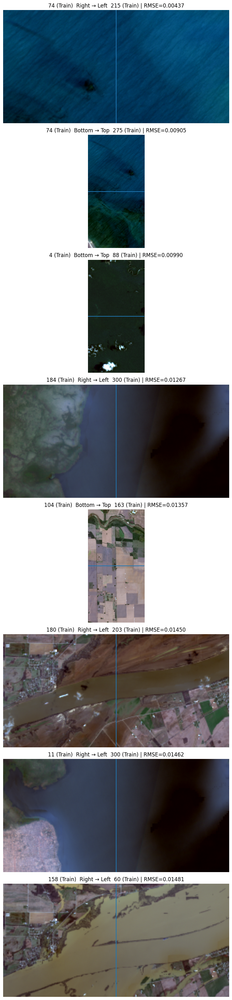

In [102]:
# ============================================================
# 14.4c Visual inspection of the strongest candidate matches
# ============================================================

def rgb_with_global_train_scaling(image):
    # Red=3, Green=2, Blue=1, scaled with training-derived P1-P99 bounds.
    rgb_indices = [3, 2, 1]
    channels = []

    for idx in rgb_indices:
        channel = np.clip(
            image[idx],
            spectral_clip_low[idx],
            spectral_clip_high[idx]
        )
        channel = (
            channel - spectral_clip_low[idx]
        ) / max(spectral_clip_high[idx] - spectral_clip_low[idx], 1e-6)
        channels.append(channel)

    return np.stack(channels, axis=-1)


def show_edge_match_candidates(match_df, top_k=8):
    top_k = min(top_k, len(match_df))

    fig, axes = plt.subplots(top_k, 1, figsize=(12, 4 * top_k))
    if top_k == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, match_df.head(top_k).iterrows()):
        source_id = str(row["Source_ID"])
        neighbor_id = str(row["Neighbor_ID"])
        direction = row["Direction"]

        with rasterio.open(image_map[source_id]) as src:
            source_img = src.read().astype(np.float32)

        with rasterio.open(image_map[neighbor_id]) as src:
            neighbor_img = src.read().astype(np.float32)

        source_rgb = rgb_with_global_train_scaling(source_img)
        neighbor_rgb = rgb_with_global_train_scaling(neighbor_img)

        if direction == "Right → Left":
            combined = np.concatenate([source_rgb, neighbor_rgb], axis=1)
            ax.imshow(combined)
            ax.axvline(source_rgb.shape[1] - 0.5, linewidth=1.5)
        else:
            combined = np.concatenate([source_rgb, neighbor_rgb], axis=0)
            ax.imshow(combined)
            ax.axhline(source_rgb.shape[0] - 0.5, linewidth=1.5)

        ax.set_title(
            f"{source_id} ({row['Source_Split']})  {direction}  "
            f"{neighbor_id} ({row['Neighbor_Split']}) | "
            f"RMSE={row['Edge_RMSE']:.5f}"
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_edge_match_candidates(edge_match_df, top_k=8)


### 14.5 Spatial Leakage – Final EDA Conclusion

The sequential-ID hypothesis is **not supported visually**: arranging consecutive IDs as 4×4 mosaics does not show convincing spatial continuity.

The dataset-wide edge-matching diagnostic provides a stronger check because it compares boundaries across all 306 patches without assuming ID order. The observed score distribution was:

- minimum Edge RMSE: **0.004373**
- P0.1: **0.075080**
- P1: **0.111372**
- P5: **0.142060**
- median: **0.264934**

A small number of candidate pairs are therefore extreme low-error outliers. Visual inspection, however, shows that the metric can be fooled by homogeneous low-contrast surfaces such as open water or very dark scenes.

One particularly low-error pair (`74 → 215`, RMSE ≈ 0.0044) appears visually plausible as neighboring ocean texture, but both patches are in the **training** split, so it does not directly contaminate validation. Among the top 20 ranked matches, three were cross-split candidates (`52 → 157`, `302 → 232`, and `43 → 283`), but the current edge metric and visual evidence are not strong enough to confirm that they are true geographic neighbors.

**Decision:** retain the current water-coverage-stratified train/validation split. There is **no convincing evidence of material spatial leakage**, but complete spatial independence cannot be guaranteed because parent-scene/geographic IDs are unavailable. This limitation should be documented in the README. If source-scene metadata becomes available later, a group-based split should be re-evaluated.

This concludes the EDA-stage spatial-leakage investigation; further analysis should not delay implementation of the preprocessing and training pipeline.

## 15. Final Training Setup

This notebook is the **clean final run-all version**. The old V1 training/ablation cells have been removed so there are no skipped cells or stale dependencies. Run the notebook from top to bottom once.

The final pipeline below follows the instructor-reviewed protocol: held-out test split, train-only preprocessing, corrected NDWI/MNDWI, in-memory caching, BatchNorm U-Net, AdamW, BCE+Dice, scheduler, multi-seed evaluation, optional ResUNet, threshold tuning, TTA, per-image IoU, and worst-case analysis.


In [103]:
# ============================================================
# 15.1 Final PyTorch / I/O / Metric Utilities
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import tifffile

FINAL_SEED = 42
random.seed(FINAL_SEED)
np.random.seed(FINAL_SEED)
torch.manual_seed(FINAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(FINAL_SEED)
    torch.cuda.manual_seed_all(FINAL_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("CUDA available :", torch.cuda.is_available())
print("Device         :", device)

def load_raw_image(image_path):
    image = tifffile.imread(image_path)
    if image.shape == (128, 128, 12):
        image = np.transpose(image, (2, 0, 1))
    if image.shape != (12, 128, 128):
        raise ValueError(f"Unexpected image shape {image.shape} for {image_path}")
    return image.astype(np.float32)

def load_binary_mask(mask_path):
    mask = np.array(Image.open(mask_path))
    if mask.ndim == 3:
        mask = mask[..., 0]
    if mask.shape != (128, 128):
        raise ValueError(f"Unexpected mask shape {mask.shape} for {mask_path}")
    return (mask > 0).astype(np.float32)

def apply_spatial_augmentation(image, mask):
    if random.random() < 0.5:
        image = np.flip(image, axis=2)
        mask = np.flip(mask, axis=1)
    if random.random() < 0.5:
        image = np.flip(image, axis=1)
        mask = np.flip(mask, axis=0)
    k = random.randint(0, 3)
    if k:
        image = np.rot90(image, k=k, axes=(1, 2))
        mask = np.rot90(mask, k=k, axes=(0, 1))
    return np.ascontiguousarray(image), np.ascontiguousarray(mask)

METRIC_EPS = 1e-8

def confusion_counts_from_logits(logits, targets, threshold=0.5):
    probabilities = torch.sigmoid(logits)
    predictions = probabilities >= threshold
    targets_bool = targets >= 0.5
    tp = int((predictions & targets_bool).sum().item())
    fp = int((predictions & (~targets_bool)).sum().item())
    fn = int(((~predictions) & targets_bool).sum().item())
    tn = int(((~predictions) & (~targets_bool)).sum().item())
    return tp, fp, fn, tn

def segmentation_metrics_from_counts(tp, fp, fn, tn, eps=METRIC_EPS):
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    iou = tp / (tp + fp + fn + eps)
    accuracy = (tp + tn) / (tp + fp + fn + tn + eps)
    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou,
        "accuracy": accuracy,
    }

print("Final setup ready.")


PyTorch version: 2.11.0+cu128
CUDA available : True
Device         : cuda
Final setup ready.


# 16. Instructor-Reviewed Final Pipeline

This is the final protocol used for conclusions. It includes a stratified train/validation/held-out-test split, train-only preprocessing statistics, corrected non-negative NDWI/MNDWI inputs, in-memory caching, BatchNorm U-Net, AdamW + scheduler, BCE+Dice loss, a 100-epoch budget with patience 15, the same runner for E0/E1/benchmark12/E4, three seeds with mean ± std, per-image IoU, threshold tuning + flip TTA, optional ResUNet, and worst-10 error analysis.

The held-out test set is never used for early stopping, model/config selection, or threshold selection.


In [104]:
# 16.1 Stratified Train / Validation / Test Split
from sklearn.model_selection import train_test_split
from pathlib import Path
import os, json, gc

V2_SEED = 42
train_v2_df, temp_v2_df = train_test_split(
    mask_distribution_df,
    test_size=0.30,
    random_state=V2_SEED,
    stratify=mask_distribution_df["Coverage_Group"],
)
val_v2_df, test_v2_df = train_test_split(
    temp_v2_df,
    test_size=0.50,
    random_state=V2_SEED,
    stratify=temp_v2_df["Coverage_Group"],
)
for _df in (train_v2_df, val_v2_df, test_v2_df):
    _df.reset_index(drop=True, inplace=True)

print("V2 split sizes")
print("Train      :", len(train_v2_df))
print("Validation :", len(val_v2_df))
print("Test       :", len(test_v2_df))
print("Total      :", len(train_v2_df)+len(val_v2_df)+len(test_v2_df))

v2_split_distribution = pd.DataFrame({
    "Full": mask_distribution_df["Coverage_Group"].value_counts(normalize=True),
    "Train": train_v2_df["Coverage_Group"].value_counts(normalize=True),
    "Validation": val_v2_df["Coverage_Group"].value_counts(normalize=True),
    "Test": test_v2_df["Coverage_Group"].value_counts(normalize=True),
}).fillna(0)*100
display(v2_split_distribution.round(2))


V2 split sizes
Train      : 214
Validation : 46
Test       : 46
Total      : 306


,Full,Train,Validation,Test
Coverage_Group,,,,
High (50-80%),15.69,15.89,15.22,15.22
Low (5-20%),15.03,14.95,15.22,15.22
Medium (20-50%),25.16,25.23,23.91,26.09
No Water,14.71,14.49,15.22,15.22
Very High (80-100%),5.88,6.07,6.52,4.35
Very Low (0-5%),23.53,23.36,23.91,23.91


### 16.2 Cache the Raw Dataset in Memory

The dataset is small enough to keep in RAM, so V2 avoids repeated TIFF/PNG reads every epoch. Preprocessing is still applied after retrieving the raw arrays.


In [105]:
# 16.2 Cache All Raw Images and Masks
from tqdm.auto import tqdm

all_ids_v2 = mask_distribution_df["Sample_ID"].astype(str).tolist()
RAW_IMAGE_CACHE_V2 = {}
MASK_CACHE_V2 = {}
for sample_id in tqdm(all_ids_v2, desc="Caching images/masks"):
    RAW_IMAGE_CACHE_V2[sample_id] = load_raw_image(image_map[sample_id])
    MASK_CACHE_V2[sample_id] = load_binary_mask(mask_map[sample_id])

cache_bytes = sum(x.nbytes for x in RAW_IMAGE_CACHE_V2.values()) + sum(x.nbytes for x in MASK_CACHE_V2.values())
print("Cached samples :", len(RAW_IMAGE_CACHE_V2))
print(f"Approx RAM use : {cache_bytes/(1024**2):.1f} MB")


Caching images/masks:   0%|          | 0/306 [00:00<?, ?it/s]

Cached samples : 306
Approx RAM use : 248.6 MB


### 16.3 Re-fit Preprocessing Statistics on Train Only

All V2 statistics are re-fitted on `train_v2_df` only. For NDWI/MNDWI, the seven spectral bands are percentile-clipped using train-only bounds and then floored at `0` **only for index calculation**. This avoids unstable ratios from negative clipped values while leaving the ordinary benchmark spectral channels unchanged.


In [106]:
# 16.3 Fit Preprocessing Statistics - TRAIN ONLY
EPS_V2 = 1e-6
GREEN_IDX, NIR_IDX, SWIR1_IDX = 2, 4, 5

def safe_normalized_difference_v2(a, b, eps=EPS_V2):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    return (a-b)/np.maximum(a+b, eps)

def fit_preprocessing_stats_v2(train_dataframe, raw_cache):
    ids = train_dataframe["Sample_ID"].astype(str).tolist()
    images = np.stack([raw_cache[sid] for sid in ids]).astype(np.float32)

    spectral_raw = images[:, :7]
    spectral_low = np.percentile(spectral_raw, 1, axis=(0,2,3)).astype(np.float32)
    spectral_high = np.percentile(spectral_raw, 99, axis=(0,2,3)).astype(np.float32)
    spectral_clip = np.clip(spectral_raw, spectral_low[None,:,None,None], spectral_high[None,:,None,None])
    spectral_mean = spectral_clip.mean(axis=(0,2,3)).astype(np.float32)
    spectral_std = np.maximum(spectral_clip.std(axis=(0,2,3)).astype(np.float32), EPS_V2)

    qa = images[:,7].astype(np.float32)
    qa_mean, qa_std = np.float32(qa.mean()), np.float32(max(float(qa.std()), EPS_V2))

    merit = images[:,8].copy(); cop = images[:,9].copy()
    missing = merit == -9999
    merit[missing] = cop[missing]
    merit_mean, merit_std = np.float32(merit.mean()), np.float32(max(float(merit.std()), EPS_V2))
    cop_mean, cop_std = np.float32(cop.mean()), np.float32(max(float(cop.std()), EPS_V2))
    rel = merit - merit.mean(axis=(1,2), keepdims=True)
    rel_mean, rel_std = np.float32(rel.mean()), np.float32(max(float(rel.std()), EPS_V2))

    wc = images[:,10].astype(np.int32)
    wc_classes = np.sort(np.unique(wc)).astype(np.int32)
    wc_float = wc.astype(np.float32)
    wc_mean, wc_std = np.float32(wc_float.mean()), np.float32(max(float(wc_float.std()), EPS_V2))

    wo = np.clip(images[:,11], 0, 100).astype(np.float32)
    wo_mean, wo_std = np.float32(wo.mean()), np.float32(max(float(wo.std()), EPS_V2))

    spec_idx = np.maximum(spectral_clip, 0.0)
    ndwi = safe_normalized_difference_v2(spec_idx[:,GREEN_IDX], spec_idx[:,NIR_IDX])
    mndwi = safe_normalized_difference_v2(spec_idx[:,GREEN_IDX], spec_idx[:,SWIR1_IDX])
    ndwi_low, ndwi_high = np.percentile(ndwi, [1,99]).astype(np.float32)
    mndwi_low, mndwi_high = np.percentile(mndwi, [1,99]).astype(np.float32)
    ndwi_c = np.clip(ndwi, ndwi_low, ndwi_high)
    mndwi_c = np.clip(mndwi, mndwi_low, mndwi_high)

    stats = {
        "spectral_clip_low": spectral_low,
        "spectral_clip_high": spectral_high,
        "spectral_mean": spectral_mean,
        "spectral_std": spectral_std,
        "qa_mean": qa_mean,
        "qa_std": qa_std,
        "merit_mean": merit_mean,
        "merit_std": merit_std,
        "copernicus_mean": cop_mean,
        "copernicus_std": cop_std,
        "relative_elevation_mean": rel_mean,
        "relative_elevation_std": rel_std,
        "worldcover_classes": wc_classes,
        "worldcover_mean": wc_mean,
        "worldcover_std": wc_std,
        "water_occ_mean": wo_mean,
        "water_occ_std": wo_std,
        "ndwi_clip_low": ndwi_low,
        "ndwi_clip_high": ndwi_high,
        "ndwi_mean": np.float32(ndwi_c.mean()),
        "ndwi_std": np.float32(max(float(ndwi_c.std()), EPS_V2)),
        "mndwi_clip_low": mndwi_low,
        "mndwi_clip_high": mndwi_high,
        "mndwi_mean": np.float32(mndwi_c.mean()),
        "mndwi_std": np.float32(max(float(mndwi_c.std()), EPS_V2)),
        "index_nonnegative_floor": 0.0,
    }
    del images, spectral_raw, spectral_clip, merit, cop
    gc.collect()
    return stats

preprocessing_stats_v2 = fit_preprocessing_stats_v2(train_v2_df, RAW_IMAGE_CACHE_V2)
print("WorldCover classes:", preprocessing_stats_v2["worldcover_classes"].tolist())
print("NDWI clip:", float(preprocessing_stats_v2["ndwi_clip_low"]), "to", float(preprocessing_stats_v2["ndwi_clip_high"]))
print("MNDWI clip:", float(preprocessing_stats_v2["mndwi_clip_low"]), "to", float(preprocessing_stats_v2["mndwi_clip_high"]))


WorldCover classes: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
NDWI clip: -0.8176770210266113 to 1.0
MNDWI clip: -0.6689038276672363 to 0.9857397675514221


In [107]:
# 16.4 Save stats.json and Split Metadata
V2_OUTPUT_DIR = Path("/kaggle/working/water_segmentation_v2")
V2_RESULTS_DIR = V2_OUTPUT_DIR / "results"
V2_CHECKPOINT_DIR = V2_OUTPUT_DIR / "checkpoints"
V2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
V2_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
V2_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

def _json_ready(value):
    if isinstance(value, np.ndarray): return value.tolist()
    if isinstance(value, (np.floating, np.integer)): return value.item()
    if isinstance(value, dict): return {k:_json_ready(v) for k,v in value.items()}
    if isinstance(value, (list, tuple)): return [_json_ready(v) for v in value]
    return value

with open(V2_OUTPUT_DIR/"stats.json", "w", encoding="utf-8") as f:
    json.dump(_json_ready(preprocessing_stats_v2), f, indent=2)

split_export = pd.concat([
    train_v2_df.assign(Split="Train"),
    val_v2_df.assign(Split="Validation"),
    test_v2_df.assign(Split="Test"),
], ignore_index=True)
split_export.to_csv(V2_OUTPUT_DIR/"split_v2.csv", index=False)
print("Saved:", V2_OUTPUT_DIR/"stats.json")
print("Saved:", V2_OUTPUT_DIR/"split_v2.csv")


Saved: /kaggle/working/water_segmentation_v2/stats.json
Saved: /kaggle/working/water_segmentation_v2/split_v2.csv


In [108]:
# 16.5 Final Feature Pipeline
V2_EXPERIMENT_CONFIGS = {
    "E0": dict(indices=False, dem=False, worldcover=False, water_occ=False, qa_bits=False),
    "E1": dict(indices=True,  dem=False, worldcover=False, water_occ=False, qa_bits=False),
    "E2": dict(indices=True,  dem=True,  worldcover=False, water_occ=False, qa_bits=False),
    "E3": dict(indices=True,  dem=True,  worldcover=True,  water_occ=False, qa_bits=False),
    "E4": dict(indices=True,  dem=True,  worldcover=True,  water_occ=True,  qa_bits=False),
    "E5": dict(indices=True,  dem=True,  worldcover=True,  water_occ=True,  qa_bits=True),
}

def preprocess_spectral_v2(image, stats):
    x = image[:7].astype(np.float32).copy()
    x = np.clip(x, stats["spectral_clip_low"][:,None,None], stats["spectral_clip_high"][:,None,None])
    return ((x-stats["spectral_mean"][:,None,None])/(stats["spectral_std"][:,None,None]+EPS_V2)).astype(np.float32)

def compute_water_indices_v2(image, stats):
    x = image[:7].astype(np.float32).copy()
    x = np.clip(x, stats["spectral_clip_low"][:,None,None], stats["spectral_clip_high"][:,None,None])
    x = np.maximum(x, stats.get("index_nonnegative_floor",0.0))
    ndwi = safe_normalized_difference_v2(x[GREEN_IDX], x[NIR_IDX])
    mndwi = safe_normalized_difference_v2(x[GREEN_IDX], x[SWIR1_IDX])
    ndwi = np.clip(ndwi, stats["ndwi_clip_low"], stats["ndwi_clip_high"])
    mndwi = np.clip(mndwi, stats["mndwi_clip_low"], stats["mndwi_clip_high"])
    ndwi = (ndwi-stats["ndwi_mean"])/(stats["ndwi_std"]+EPS_V2)
    mndwi = (mndwi-stats["mndwi_mean"])/(stats["mndwi_std"]+EPS_V2)
    return np.stack([ndwi,mndwi]).astype(np.float32)

def preprocess_12ch_benchmark_v2(image, stats):
    image = np.asarray(image, dtype=np.float32)
    out = np.empty_like(image, dtype=np.float32)
    out[:7] = preprocess_spectral_v2(image, stats)
    out[7] = (image[7]-stats["qa_mean"])/(stats["qa_std"]+EPS_V2)
    merit = image[8].copy(); cop = image[9].copy(); missing = merit == -9999; merit[missing] = cop[missing]
    out[8] = (merit-stats["merit_mean"])/(stats["merit_std"]+EPS_V2)
    out[9] = (cop-stats["copernicus_mean"])/(stats["copernicus_std"]+EPS_V2)
    out[10] = (image[10]-stats["worldcover_mean"])/(stats["worldcover_std"]+EPS_V2)
    wo = np.clip(image[11],0,100)
    out[11] = (wo-stats["water_occ_mean"])/(stats["water_occ_std"]+EPS_V2)
    if not np.isfinite(out).all(): raise ValueError("benchmark12 V2 produced NaN/Inf")
    return out.astype(np.float32)

def build_experiment_features_v2(image, experiment, stats):
    cfg = V2_EXPERIMENT_CONFIGS[experiment]
    blocks = [preprocess_spectral_v2(image, stats)]
    if cfg["indices"]: blocks.append(compute_water_indices_v2(image, stats))
    if cfg["dem"]:
        merit = image[8].copy(); cop = image[9]; missing = merit == -9999; merit[missing] = cop[missing]
        merit_n = (merit-stats["merit_mean"])/(stats["merit_std"]+EPS_V2)
        rel = merit-merit.mean(); rel = (rel-stats["relative_elevation_mean"])/(stats["relative_elevation_std"]+EPS_V2)
        blocks.append(np.stack([merit_n,rel]).astype(np.float32))
    if cfg["worldcover"]:
        wc = image[10].astype(np.int32)
        blocks.append(np.stack([(wc==int(c)).astype(np.float32) for c in stats["worldcover_classes"]]))
    if cfg["water_occ"]:
        wo = np.clip(image[11],0,100); wo=(wo-stats["water_occ_mean"])/(stats["water_occ_std"]+EPS_V2)
        blocks.append(wo[None].astype(np.float32))
    if cfg["qa_bits"]:
        qa = image[7].astype(np.uint16)
        blocks.append(np.stack([((qa>>bit)&1).astype(np.float32) for bit in range(8)]))
    feat = np.concatenate(blocks,axis=0).astype(np.float32)
    if not np.isfinite(feat).all(): raise ValueError(f"{experiment} V2 produced NaN/Inf")
    return feat

example_id_v2 = str(train_v2_df.iloc[0]["Sample_ID"])
example_raw_v2 = RAW_IMAGE_CACHE_V2[example_id_v2]
shape_rows=[]
for mode in ["benchmark12",*V2_EXPERIMENT_CONFIGS.keys()]:
    feat = preprocess_12ch_benchmark_v2(example_raw_v2, preprocessing_stats_v2) if mode=="benchmark12" else build_experiment_features_v2(example_raw_v2, mode, preprocessing_stats_v2)
    shape_rows.append({"Mode":mode,"Channels":feat.shape[0],"Shape":str(feat.shape)})
display(pd.DataFrame(shape_rows))


,Mode,Channels,Shape
0,benchmark12,12,"(12, 128, 128)"
1,E0,7,"(7, 128, 128)"
2,E1,9,"(9, 128, 128)"
3,E2,11,"(11, 128, 128)"
4,E3,21,"(21, 128, 128)"
5,E4,22,"(22, 128, 128)"
6,E5,30,"(30, 128, 128)"


# 17. Final Dataset and DataLoaders

V2 reads from the in-memory cache. `num_workers=0` is intentional because the data are already in RAM and this avoids duplicating the cache across worker processes.


In [109]:
# 17.1 Cached Dataset and Deterministic Loaders
class WaterSegmentationDatasetV2(Dataset):
    def __init__(self, dataframe, raw_cache, mask_cache, stats, input_mode, augment=False):
        self.df = dataframe.reset_index(drop=True).copy()
        self.raw_cache = raw_cache; self.mask_cache = mask_cache; self.stats = stats
        self.input_mode = input_mode; self.augment = augment
        valid = ["benchmark12", *V2_EXPERIMENT_CONFIGS.keys()]
        if input_mode not in valid: raise ValueError(f"input_mode must be one of {valid}")
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        sid = str(self.df.iloc[idx]["Sample_ID"])
        raw = self.raw_cache[sid]; mask = self.mask_cache[sid].copy()
        feat = preprocess_12ch_benchmark_v2(raw,self.stats) if self.input_mode=="benchmark12" else build_experiment_features_v2(raw,self.input_mode,self.stats)
        if self.augment: feat, mask = apply_spatial_augmentation(feat, mask)
        return {"image":torch.from_numpy(np.ascontiguousarray(feat)).float(), "mask":torch.from_numpy(np.ascontiguousarray(mask)).float().unsqueeze(0), "sample_id":sid}

def set_global_seed_v2(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False

def create_v2_loaders(input_mode, seed, batch_size=16):
    set_global_seed_v2(seed)
    train_ds=WaterSegmentationDatasetV2(train_v2_df,RAW_IMAGE_CACHE_V2,MASK_CACHE_V2,preprocessing_stats_v2,input_mode,True)
    val_ds=WaterSegmentationDatasetV2(val_v2_df,RAW_IMAGE_CACHE_V2,MASK_CACHE_V2,preprocessing_stats_v2,input_mode,False)
    test_ds=WaterSegmentationDatasetV2(test_v2_df,RAW_IMAGE_CACHE_V2,MASK_CACHE_V2,preprocessing_stats_v2,input_mode,False)
    g=torch.Generator().manual_seed(seed)
    train_loader=DataLoader(train_ds,batch_size=batch_size,shuffle=True,num_workers=0,pin_memory=torch.cuda.is_available(),generator=g)
    val_loader=DataLoader(val_ds,batch_size=batch_size,shuffle=False,num_workers=0,pin_memory=torch.cuda.is_available())
    test_loader=DataLoader(test_ds,batch_size=batch_size,shuffle=False,num_workers=0,pin_memory=torch.cuda.is_available())
    return train_ds,val_ds,test_ds,train_loader,val_loader,test_loader


# 18. Improved U-Net

The final U-Net remains from scratch, but each double-convolution block now uses BatchNorm. V2 uses `AdamW`, `BCE + Dice`, `ReduceLROnPlateau`, up to 100 epochs, and early-stopping patience 15. A lightweight ResUNet is included as a targeted fallback if the engineered E4 configuration still does not clearly beat benchmark12.


In [110]:
# 18.1 BatchNorm U-Net and Optional ResUNet
import torch.nn.functional as F

class DoubleConvBN(nn.Module):
    def __init__(self,in_channels,out_channels):
        super().__init__(); self.block=nn.Sequential(
            nn.Conv2d(in_channels,out_channels,3,padding=1,bias=False),nn.BatchNorm2d(out_channels),nn.ReLU(inplace=True),
            nn.Conv2d(out_channels,out_channels,3,padding=1,bias=False),nn.BatchNorm2d(out_channels),nn.ReLU(inplace=True))
    def forward(self,x): return self.block(x)

class UNetV2(nn.Module):
    def __init__(self,in_channels,out_channels=1,base_features=32):
        super().__init__(); f=base_features; self.pool=nn.MaxPool2d(2)
        self.enc1=DoubleConvBN(in_channels,f); self.enc2=DoubleConvBN(f,f*2); self.enc3=DoubleConvBN(f*2,f*4); self.enc4=DoubleConvBN(f*4,f*8); self.bottleneck=DoubleConvBN(f*8,f*16)
        self.up4=nn.ConvTranspose2d(f*16,f*8,2,2); self.dec4=DoubleConvBN(f*16,f*8)
        self.up3=nn.ConvTranspose2d(f*8,f*4,2,2); self.dec3=DoubleConvBN(f*8,f*4)
        self.up2=nn.ConvTranspose2d(f*4,f*2,2,2); self.dec2=DoubleConvBN(f*4,f*2)
        self.up1=nn.ConvTranspose2d(f*2,f,2,2); self.dec1=DoubleConvBN(f*2,f); self.final=nn.Conv2d(f,out_channels,1)
    def forward(self,x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3)); b=self.bottleneck(self.pool(e4))
        d4=self.dec4(torch.cat([self.up4(b),e4],1)); d3=self.dec3(torch.cat([self.up3(d4),e3],1)); d2=self.dec2(torch.cat([self.up2(d3),e2],1)); d1=self.dec1(torch.cat([self.up1(d2),e1],1)); return self.final(d1)

class ResidualBlockBN(nn.Module):
    def __init__(self,in_channels,out_channels):
        super().__init__(); self.c1=nn.Conv2d(in_channels,out_channels,3,padding=1,bias=False); self.b1=nn.BatchNorm2d(out_channels); self.c2=nn.Conv2d(out_channels,out_channels,3,padding=1,bias=False); self.b2=nn.BatchNorm2d(out_channels); self.relu=nn.ReLU(inplace=True)
        self.short=nn.Identity() if in_channels==out_channels else nn.Sequential(nn.Conv2d(in_channels,out_channels,1,bias=False),nn.BatchNorm2d(out_channels))
    def forward(self,x):
        r=self.short(x); y=self.relu(self.b1(self.c1(x))); y=self.b2(self.c2(y)); return self.relu(y+r)

class ResUNetV2(nn.Module):
    def __init__(self,in_channels,out_channels=1,base_features=32):
        super().__init__(); f=base_features; self.pool=nn.MaxPool2d(2)
        self.enc1=ResidualBlockBN(in_channels,f); self.enc2=ResidualBlockBN(f,f*2); self.enc3=ResidualBlockBN(f*2,f*4); self.enc4=ResidualBlockBN(f*4,f*8); self.bottleneck=ResidualBlockBN(f*8,f*16)
        self.up4=nn.ConvTranspose2d(f*16,f*8,2,2); self.dec4=ResidualBlockBN(f*16,f*8); self.up3=nn.ConvTranspose2d(f*8,f*4,2,2); self.dec3=ResidualBlockBN(f*8,f*4); self.up2=nn.ConvTranspose2d(f*4,f*2,2,2); self.dec2=ResidualBlockBN(f*4,f*2); self.up1=nn.ConvTranspose2d(f*2,f,2,2); self.dec1=ResidualBlockBN(f*2,f); self.final=nn.Conv2d(f,out_channels,1)
    def forward(self,x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3)); b=self.bottleneck(self.pool(e4)); d4=self.dec4(torch.cat([self.up4(b),e4],1)); d3=self.dec3(torch.cat([self.up3(d4),e3],1)); d2=self.dec2(torch.cat([self.up2(d3),e2],1)); d1=self.dec1(torch.cat([self.up1(d2),e1],1)); return self.final(d1)

def build_model_v2(architecture,in_channels,base_features=32):
    if architecture=="UNetBN": return UNetV2(in_channels,1,base_features)
    if architecture=="ResUNetBN": return ResUNetV2(in_channels,1,base_features)
    raise ValueError(architecture)

class BCEDiceLoss(nn.Module):
    def __init__(self,smooth=1.0): super().__init__(); self.smooth=smooth
    def forward(self,logits,targets):
        bce=F.binary_cross_entropy_with_logits(logits,targets); p=torch.sigmoid(logits).flatten(1); t=targets.flatten(1); inter=(p*t).sum(1); dice=(2*inter+self.smooth)/(p.sum(1)+t.sum(1)+self.smooth); return bce+(1-dice.mean())

criterion_v2=BCEDiceLoss(); print(criterion_v2)


BCEDiceLoss()


# 19. Training and Evaluation Utilities

Checkpoint selection uses global validation IoU only. The test loader is never called inside training. Final evaluation reports global IoU and mean per-image IoU.


In [111]:
# 19.1 AMP-aware Train / Validation Loops
AMP_ENABLED_V2=torch.cuda.is_available()
def make_scaler_v2():
    if not AMP_ENABLED_V2: return None
    try: return torch.amp.GradScaler("cuda",enabled=True)
    except Exception: return torch.cuda.amp.GradScaler(enabled=True)
def autocast_v2(): return torch.autocast(device_type="cuda" if torch.cuda.is_available() else "cpu",dtype=torch.float16 if torch.cuda.is_available() else torch.bfloat16,enabled=AMP_ENABLED_V2)

def train_one_epoch_v2(model,loader,optimizer,criterion,device,scaler=None):
    model.train(); loss_sum=0.0; n=0; tp=fp=fn=tn=0
    for batch in loader:
        x=batch["image"].to(device,non_blocking=True); y=batch["mask"].to(device,non_blocking=True); optimizer.zero_grad(set_to_none=True)
        with autocast_v2(): logits=model(x); loss=criterion(logits,y)
        if scaler is not None: scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        else: loss.backward(); optimizer.step()
        bs=x.size(0); loss_sum+=loss.item()*bs; n+=bs; a,b,c,d=confusion_counts_from_logits(logits,y,0.5); tp+=a; fp+=b; fn+=c; tn+=d
    m=segmentation_metrics_from_counts(tp,fp,fn,tn); m["loss"]=loss_sum/max(n,1); return m

@torch.no_grad()
def validate_one_epoch_v2(model,loader,criterion,device):
    model.eval(); loss_sum=0.0; n=0; tp=fp=fn=tn=0
    for batch in loader:
        x=batch["image"].to(device,non_blocking=True); y=batch["mask"].to(device,non_blocking=True)
        with autocast_v2(): logits=model(x); loss=criterion(logits,y)
        bs=x.size(0); loss_sum+=loss.item()*bs; n+=bs; a,b,c,d=confusion_counts_from_logits(logits,y,0.5); tp+=a; fp+=b; fn+=c; tn+=d
    m=segmentation_metrics_from_counts(tp,fp,fn,tn); m["loss"]=loss_sum/max(n,1); return m


In [112]:
# 19.2 Detailed Evaluation, Per-image IoU, and Flip TTA
@torch.no_grad()
def predict_probabilities_v2(model,images,use_tta=False):
    model.eval()
    def fp(x):
        with autocast_v2(): return torch.sigmoid(model(x))
    probs=[fp(images)]
    if use_tta:
        for dims in [(-1,),(-2,),(-2,-1)]: probs.append(torch.flip(fp(torch.flip(images,dims=dims)),dims=dims))
    return torch.stack(probs).mean(0)

def counts_from_probabilities_v2(probs,targets,threshold):
    p=probs>=threshold; t=targets>=0.5; return int((p&t).sum()),int((p&~t).sum()),int((~p&t).sum()),int((~p&~t).sum())

@torch.no_grad()
def evaluate_loader_v2(model,loader,device,threshold=0.5,use_tta=False):
    model.eval(); TP=FP=FN=TN=0; rows=[]
    for batch in loader:
        x=batch["image"].to(device,non_blocking=True); y=batch["mask"].to(device,non_blocking=True); probs=predict_probabilities_v2(model,x,use_tta); a,b,c,d=counts_from_probabilities_v2(probs,y,threshold); TP+=a; FP+=b; FN+=c; TN+=d
        pred=probs>=threshold; target=y>=0.5
        for i,sid in enumerate(batch["sample_id"]):
            p=pred[i,0]; t=target[i,0]; tp=int((p&t).sum()); fp=int((p&~t).sum()); fn=int((~p&t).sum()); union=tp+fp+fn; iou=1.0 if union==0 else tp/union
            rows.append({"Sample_ID":str(sid),"IoU":float(iou),"GT_Water_%":float(t.float().mean()*100),"Pred_Water_%":float(p.float().mean()*100)})
    m=segmentation_metrics_from_counts(TP,FP,FN,TN); per=pd.DataFrame(rows); m["mean_per_image_iou"]=float(per["IoU"].mean()); return m,per


In [113]:
# 19.3 Reusable Final Runner - Test Set Is NOT Evaluated Here
def run_experiment_v2(experiment_name,seed,architecture="UNetBN",num_epochs=100,patience=15,learning_rate=1e-3,weight_decay=1e-4,batch_size=16,base_features=32,scheduler_patience=5,min_delta=1e-4):
    print("="*76); print(f"V2 | {architecture} | {experiment_name} | seed={seed}"); print("="*76)
    set_global_seed_v2(seed)
    train_ds,val_ds,_test_ds,train_loader,val_loader,_test_loader=create_v2_loaders(experiment_name,seed,batch_size)
    in_channels=int(train_ds[0]["image"].shape[0]); model=build_model_v2(architecture,in_channels,base_features).to(device)
    criterion=BCEDiceLoss(); optimizer=torch.optim.AdamW(model.parameters(),lr=learning_rate,weight_decay=weight_decay)
    scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="max",factor=0.5,patience=scheduler_patience,min_lr=1e-6); scaler=make_scaler_v2()
    ckpt=V2_CHECKPOINT_DIR/f"{architecture}_{experiment_name}_seed{seed}.pth"; best=-np.inf; best_epoch=0; no_imp=0; history=[]
    for epoch in range(1,num_epochs+1):
        tr=train_one_epoch_v2(model,train_loader,optimizer,criterion,device,scaler); va=validate_one_epoch_v2(model,val_loader,criterion,device); scheduler.step(va["iou"]); lr=optimizer.param_groups[0]["lr"]
        history.append({"Epoch":epoch,"Train_Loss":tr["loss"],"Train_IoU":tr["iou"],"Train_F1":tr["f1"],"Val_Loss":va["loss"],"Val_IoU":va["iou"],"Val_F1":va["f1"],"Val_Precision":va["precision"],"Val_Recall":va["recall"],"LR":lr})
        print(f"Epoch {epoch:03d}/{num_epochs} | Train IoU {tr['iou']:.4f} | Val IoU {va['iou']:.4f} | F1 {va['f1']:.4f} | P {va['precision']:.4f} | R {va['recall']:.4f} | LR {lr:.2e}")
        if va["iou"]>best+min_delta:
            best=va["iou"]; best_epoch=epoch; no_imp=0
            torch.save({"architecture":architecture,"experiment":experiment_name,"seed":seed,"in_channels":in_channels,"base_features":base_features,"epoch":epoch,"model_state_dict":model.state_dict(),"val_iou":va["iou"]},ckpt)
            print(f"  -> checkpoint saved ({best:.4f})")
        else: no_imp+=1
        if no_imp>=patience: print(f"  -> early stopping after {patience} non-improving epochs"); break
    hist=pd.DataFrame(history); hist_path=V2_RESULTS_DIR/f"history_{architecture}_{experiment_name}_seed{seed}.csv"; hist.to_csv(hist_path,index=False)
    state=torch.load(ckpt,map_location=device); model.load_state_dict(state["model_state_dict"])
    val_m,_=evaluate_loader_v2(model,val_loader,device,0.5,False)
    result={"Architecture":architecture,"Experiment":experiment_name,"Seed":int(seed),"In_Channels":in_channels,"Best_Epoch":int(best_epoch),"Val_Global_IoU":float(val_m["iou"]),"Val_Mean_Image_IoU":float(val_m["mean_per_image_iou"]),"Val_F1":float(val_m["f1"]),"Val_Precision":float(val_m["precision"]),"Val_Recall":float(val_m["recall"]),"Checkpoint":str(ckpt),"History":str(hist_path)}
    print(); print("BEST CHECKPOINT (VALIDATION ONLY)"); print("Best epoch:",best_epoch); print(f"Val IoU: {result['Val_Global_IoU']:.4f}"); print(f"Val mean-image IoU: {result['Val_Mean_Image_IoU']:.4f}"); print(f"Val F1: {result['Val_F1']:.4f}")
    del model; gc.collect();
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return result,hist


# 20. Core Multi-Seed Experiments

Re-run E0, E1, benchmark12, and E4 with the exact same V2 protocol for seeds 42, 123, and 2026. These core tables report **validation mean ± standard deviation only**. The held-out test set remains untouched until the final engineered configuration is selected.


In [114]:
V2_CORE_EXPERIMENTS=["E0","E1","benchmark12","E4"]
V2_SEEDS=[42,123,2026]
v2_core_results=[]; v2_histories={}
for experiment in V2_CORE_EXPERIMENTS:
    for seed in V2_SEEDS:
        result,hist=run_experiment_v2(experiment,seed,architecture="UNetBN",num_epochs=100,patience=15,learning_rate=1e-3,weight_decay=1e-4,batch_size=16,base_features=32,scheduler_patience=5)
        v2_core_results.append(result); v2_histories[("UNetBN",experiment,seed)]=hist
v2_results_df=pd.DataFrame(v2_core_results)
v2_results_df.to_csv(V2_RESULTS_DIR/"core_multiseed_results.csv",index=False)
display(v2_results_df.round(4))

def summarize_multiseed_v2(df):
    return (df.groupby(["Architecture","Experiment"],as_index=False).agg(
        Seeds=("Seed","count"),Best_Epoch_Mean=("Best_Epoch","mean"),
        Val_IoU_Mean=("Val_Global_IoU","mean"),Val_IoU_Std=("Val_Global_IoU","std"),
        Val_MeanImageIoU_Mean=("Val_Mean_Image_IoU","mean"),Val_MeanImageIoU_Std=("Val_Mean_Image_IoU","std"),
        Val_F1_Mean=("Val_F1","mean"),Val_F1_Std=("Val_F1","std"),
        Val_Precision_Mean=("Val_Precision","mean"),Val_Recall_Mean=("Val_Recall","mean")
    ).sort_values("Val_IoU_Mean",ascending=False).reset_index(drop=True))

v2_summary_df=summarize_multiseed_v2(v2_results_df)
v2_summary_df.to_csv(V2_RESULTS_DIR/"core_multiseed_summary.csv",index=False)
display(v2_summary_df.round(4))


V2 | UNetBN | E0 | seed=42
Epoch 001/100 | Train IoU 0.5020 | Val IoU 0.6072 | F1 0.7556 | P 0.6973 | R 0.8246 | LR 1.00e-03
  -> checkpoint saved (0.6072)
Epoch 002/100 | Train IoU 0.6467 | Val IoU 0.6804 | F1 0.8098 | P 0.8535 | R 0.7704 | LR 1.00e-03
  -> checkpoint saved (0.6804)
Epoch 003/100 | Train IoU 0.6556 | Val IoU 0.6597 | F1 0.7950 | P 0.8083 | R 0.7820 | LR 1.00e-03
Epoch 004/100 | Train IoU 0.6393 | Val IoU 0.6587 | F1 0.7942 | P 0.8059 | R 0.7829 | LR 1.00e-03
Epoch 005/100 | Train IoU 0.6429 | Val IoU 0.6245 | F1 0.7688 | P 0.7381 | R 0.8022 | LR 1.00e-03
Epoch 006/100 | Train IoU 0.6762 | Val IoU 0.6869 | F1 0.8144 | P 0.8537 | R 0.7785 | LR 1.00e-03
  -> checkpoint saved (0.6869)
Epoch 007/100 | Train IoU 0.6715 | Val IoU 0.7166 | F1 0.8349 | P 0.8953 | R 0.7821 | LR 1.00e-03
  -> checkpoint saved (0.7166)
Epoch 008/100 | Train IoU 0.6610 | Val IoU 0.7001 | F1 0.8236 | P 0.8793 | R 0.7745 | LR 1.00e-03
Epoch 009/100 | Train IoU 0.6669 | Val IoU 0.7092 | F1 0.8298 | P

,Architecture,Experiment,Seed,In_Channels,Best_Epoch,Val_Global_IoU,Val_Mean_Image_IoU,Val_F1,Val_Precision,Val_Recall,Checkpoint,History
0,UNetBN,E0,42,7,50,0.7577,0.6097,0.8621,0.8799,0.8451,/kaggle/working/water_segmentation_v2/checkpoi...,/kaggle/working/water_segmentation_v2/results/...
1,UNetBN,E0,123,7,81,0.7584,0.6358,0.8626,0.8787,0.8471,/kaggle/working/water_segmentation_v2/checkpoi...,/kaggle/working/water_segmentation_v2/results/...
2,UNetBN,E0,2026,7,50,0.7508,0.5779,0.8577,0.8782,0.8381,/kaggle/working/water_segmentation_v2/checkpoi...,/kaggle/working/water_segmentation_v2/results/...
3,UNetBN,E1,42,9,72,0.7579,0.6382,0.8623,0.8618,0.8627,/kaggle/working/water_segmentation_v2/checkpoi...,/kaggle/working/water_segmentation_v2/results/...
4,UNetBN,E1,123,9,53,0.7556,0.6283,0.8608,0.8684,0.8532,/kaggle/working/water_segmentation_v2/checkpoi...,/kaggle/working/water_segmentation_v2/results/...
5,UNetBN,E1,2026,9,46,0.7566,0.6364,0.8614,0.8830,0.8410,/kaggle/working/water_segmentation_v2/checkpoi...,/kaggle/working/water_segmentation_v2/results/...
6,UNetBN,benchmark12,42,12,17,0.7563,0.6216,0.8613,0.9002,0.8255,/kaggle/working/water_segmentation_v2/checkpoi...,/kaggle/working/water_segmentation_v2/results/...
7,UNetBN,benchmark12,123,12,9,0.7522,0.6137,0.8586,0.9009,0.8201,/kaggle/working/water_segmentation_v2/checkpoi...,/kaggle/working/water_segmentation_v2/results/...
8,UNetBN,benchmark12,2026,12,30,0.7542,0.6238,0.8599,0.8904,0.8314,/kaggle/working/water_segmentation_v2/checkpoi...,/kaggle/working/water_segmentation_v2/results/...
9,UNetBN,E4,42,22,12,0.7438,0.6004,0.8531,0.8851,0.8232,/kaggle/working/water_segmentation_v2/checkpoi...,/kaggle/working/water_segmentation_v2/results/...


,Architecture,Experiment,Seeds,Best_Epoch_Mean,Val_IoU_Mean,Val_IoU_Std,Val_MeanImageIoU_Mean,Val_MeanImageIoU_Std,Val_F1_Mean,Val_F1_Std,Val_Precision_Mean,Val_Recall_Mean
0,UNetBN,E1,3,57.0000,0.7567,0.0012,0.6343,0.0053,0.8615,0.0008,0.8711,0.8523
1,UNetBN,E0,3,60.3333,0.7557,0.0042,0.6078,0.0290,0.8608,0.0027,0.8789,0.8434
2,UNetBN,benchmark12,3,18.6667,0.7542,0.0021,0.6197,0.0053,0.8599,0.0013,0.8972,0.8257
3,UNetBN,E4,3,19.3333,0.7467,0.0074,0.5953,0.0179,0.8549,0.0048,0.8756,0.8358


# 21. Conditional ResUNet Upgrade

If E4 is still within 0.01 mean validation IoU of benchmark12, run ResUNetBN on E4 with the same three seeds. The 0.01 margin is a practical trigger, not a significance test.


In [115]:
MIN_CLEAR_VAL_MARGIN=0.01
bench_val=float(v2_summary_df.loc[(v2_summary_df.Architecture=="UNetBN")&(v2_summary_df.Experiment=="benchmark12"),"Val_IoU_Mean"].iloc[0])
e4_val=float(v2_summary_df.loc[(v2_summary_df.Architecture=="UNetBN")&(v2_summary_df.Experiment=="E4"),"Val_IoU_Mean"].iloc[0])
resunet_results=[]
if e4_val-bench_val < MIN_CLEAR_VAL_MARGIN:
    for seed in V2_SEEDS:
        result,hist=run_experiment_v2("E4",seed,architecture="ResUNetBN",num_epochs=100,patience=15,learning_rate=1e-3,weight_decay=1e-4,batch_size=16)
        resunet_results.append(result); v2_histories[("ResUNetBN","E4",seed)]=hist
else:
    print("ResUNet skipped: E4 already has >=0.01 mean validation-IoU margin.")
v2_results_df_all=pd.concat([v2_results_df,pd.DataFrame(resunet_results)],ignore_index=True) if resunet_results else v2_results_df.copy()
v2_summary_all_df=summarize_multiseed_v2(v2_results_df_all)
v2_results_df_all.to_csv(V2_RESULTS_DIR/"all_multiseed_results.csv",index=False)
v2_summary_all_df.to_csv(V2_RESULTS_DIR/"all_multiseed_summary.csv",index=False)
display(v2_summary_all_df.round(4))


V2 | ResUNetBN | E4 | seed=42
Epoch 001/100 | Train IoU 0.6176 | Val IoU 0.7140 | F1 0.8331 | P 0.9230 | R 0.7592 | LR 1.00e-03
  -> checkpoint saved (0.7140)
Epoch 002/100 | Train IoU 0.6734 | Val IoU 0.7172 | F1 0.8353 | P 0.9190 | R 0.7655 | LR 1.00e-03
  -> checkpoint saved (0.7172)
Epoch 003/100 | Train IoU 0.6838 | Val IoU 0.7230 | F1 0.8392 | P 0.9236 | R 0.7690 | LR 1.00e-03
  -> checkpoint saved (0.7230)
Epoch 004/100 | Train IoU 0.6648 | Val IoU 0.7205 | F1 0.8375 | P 0.9203 | R 0.7685 | LR 1.00e-03
Epoch 005/100 | Train IoU 0.6834 | Val IoU 0.7171 | F1 0.8353 | P 0.8689 | R 0.8042 | LR 1.00e-03
Epoch 006/100 | Train IoU 0.7135 | Val IoU 0.7022 | F1 0.8250 | P 0.8537 | R 0.7983 | LR 1.00e-03
Epoch 007/100 | Train IoU 0.7011 | Val IoU 0.7330 | F1 0.8459 | P 0.9045 | R 0.7945 | LR 1.00e-03
  -> checkpoint saved (0.7330)
Epoch 008/100 | Train IoU 0.7074 | Val IoU 0.7347 | F1 0.8470 | P 0.8653 | R 0.8295 | LR 1.00e-03
  -> checkpoint saved (0.7347)
Epoch 009/100 | Train IoU 0.706

,Architecture,Experiment,Seeds,Best_Epoch_Mean,Val_IoU_Mean,Val_IoU_Std,Val_MeanImageIoU_Mean,Val_MeanImageIoU_Std,Val_F1_Mean,Val_F1_Std,Val_Precision_Mean,Val_Recall_Mean
0,ResUNetBN,E4,3,91.0000,0.7936,0.0112,0.6750,0.0107,0.8849,0.0070,0.8971,0.8731
1,UNetBN,E1,3,57.0000,0.7567,0.0012,0.6343,0.0053,0.8615,0.0008,0.8711,0.8523
2,UNetBN,E0,3,60.3333,0.7557,0.0042,0.6078,0.0290,0.8608,0.0027,0.8789,0.8434
3,UNetBN,benchmark12,3,18.6667,0.7542,0.0021,0.6197,0.0053,0.8599,0.0013,0.8972,0.8257
4,UNetBN,E4,3,19.3333,0.7467,0.0074,0.5953,0.0179,0.8549,0.0048,0.8756,0.8358


# 22. Final Candidate Selection + Fair Post-Processing

Select the engineered final candidate by mean validation IoU only. Then tune the threshold on validation and apply the same flip-TTA procedure to both benchmark12 and the selected final model before evaluating held-out test.


In [116]:
# 22.1 Select Final on Validation, Then Evaluate Held-out Test Fairly
candidate=v2_summary_all_df[v2_summary_all_df.Experiment.isin(["E1","E4"])].sort_values("Val_IoU_Mean",ascending=False).iloc[0]
FINAL_ARCHITECTURE_V2=str(candidate.Architecture); FINAL_EXPERIMENT_V2=str(candidate.Experiment)
print("Selected on validation only:",FINAL_ARCHITECTURE_V2,FINAL_EXPERIMENT_V2,"| Val mean IoU",f"{candidate.Val_IoU_Mean:.4f}")

def load_v2_model_from_result(row):
    state=torch.load(row["Checkpoint"],map_location=device); model=build_model_v2(state["architecture"],state["in_channels"],state.get("base_features",32)).to(device); model.load_state_dict(state["model_state_dict"]); model.eval(); return model

@torch.no_grad()
def tune_threshold_v2(model,val_loader):
    probs=[]; targets=[]
    for batch in val_loader:
        x=batch["image"].to(device); y=batch["mask"].to(device); p=predict_probabilities_v2(model,x,True); probs.append(p.cpu().numpy().ravel()); targets.append(y.cpu().numpy().ravel())
    probs=np.concatenate(probs); targets=np.concatenate(targets)>=0.5; rows=[]
    for th in np.arange(0.25,0.751,0.025):
        pr=probs>=th; tp=int(np.logical_and(pr,targets).sum()); fp=int(np.logical_and(pr,~targets).sum()); fn=int(np.logical_and(~pr,targets).sum()); tn=int(np.logical_and(~pr,~targets).sum()); m=segmentation_metrics_from_counts(tp,fp,fn,tn); rows.append({"Threshold":float(th),**m})
    df=pd.DataFrame(rows); best=df.sort_values(["iou","f1"],ascending=False).iloc[0]; return float(best.Threshold),df

# Test is touched for the first time here, after config selection.
post_rows=[]
for arch,exp in [("UNetBN","benchmark12"),(FINAL_ARCHITECTURE_V2,FINAL_EXPERIMENT_V2)]:
    rows=v2_results_df_all[(v2_results_df_all.Architecture==arch)&(v2_results_df_all.Experiment==exp)]
    for _,row in rows.iterrows():
        seed=int(row.Seed); _,_,_,_,val_loader,test_loader=create_v2_loaders(exp,seed,16); model=load_v2_model_from_result(row)
        base_m,_=evaluate_loader_v2(model,test_loader,device,0.5,False)
        th,_=tune_threshold_v2(model,val_loader); tta_m,_=evaluate_loader_v2(model,test_loader,device,th,True)
        post_rows.append({"Architecture":arch,"Experiment":exp,"Seed":seed,"Threshold":th,
            "Test_Base_IoU":base_m["iou"],"Test_Base_MeanImageIoU":base_m["mean_per_image_iou"],"Test_Base_F1":base_m["f1"],
            "Test_TTA_IoU":tta_m["iou"],"Test_TTA_MeanImageIoU":tta_m["mean_per_image_iou"],"Test_TTA_F1":tta_m["f1"],"Test_TTA_Precision":tta_m["precision"],"Test_TTA_Recall":tta_m["recall"]})
        del model
        if torch.cuda.is_available(): torch.cuda.empty_cache()
postprocess_df=pd.DataFrame(post_rows); postprocess_df.to_csv(V2_RESULTS_DIR/"final_vs_benchmark_test_results.csv",index=False); display(postprocess_df.round(4))
postprocess_summary=postprocess_df.groupby(["Architecture","Experiment"],as_index=False).agg(
    Seeds=("Seed","count"),Threshold_Mean=("Threshold","mean"),
    Test_Base_IoU_Mean=("Test_Base_IoU","mean"),Test_Base_IoU_Std=("Test_Base_IoU","std"),Test_Base_F1_Mean=("Test_Base_F1","mean"),
    Test_TTA_IoU_Mean=("Test_TTA_IoU","mean"),Test_TTA_IoU_Std=("Test_TTA_IoU","std"),Test_TTA_F1_Mean=("Test_TTA_F1","mean"),Test_TTA_F1_Std=("Test_TTA_F1","std"),
    Test_TTA_MeanImageIoU_Mean=("Test_TTA_MeanImageIoU","mean"),Test_TTA_Precision_Mean=("Test_TTA_Precision","mean"),Test_TTA_Recall_Mean=("Test_TTA_Recall","mean"))
display(postprocess_summary.round(4))


Selected on validation only: ResUNetBN E4 | Val mean IoU 0.7936


,Architecture,Experiment,Seed,Threshold,Test_Base_IoU,Test_Base_MeanImageIoU,Test_Base_F1,Test_TTA_IoU,Test_TTA_MeanImageIoU,Test_TTA_F1,Test_TTA_Precision,Test_TTA_Recall
0,UNetBN,benchmark12,42,0.475,0.6792,0.5835,0.8090,0.6793,0.6076,0.8090,0.8456,0.7755
1,UNetBN,benchmark12,123,0.500,0.6840,0.6112,0.8124,0.6839,0.5888,0.8123,0.8604,0.7692
2,UNetBN,benchmark12,2026,0.500,0.6903,0.6044,0.8168,0.6920,0.6069,0.8180,0.8412,0.7960
3,ResUNetBN,E4,42,0.425,0.7409,0.6610,0.8512,0.7452,0.6689,0.8540,0.8318,0.8774
4,ResUNetBN,E4,123,0.450,0.7399,0.6510,0.8505,0.7405,0.6510,0.8509,0.8447,0.8572
5,ResUNetBN,E4,2026,0.425,0.7408,0.6474,0.8511,0.7381,0.6494,0.8493,0.8347,0.8645


,Architecture,Experiment,Seeds,Threshold_Mean,Test_Base_IoU_Mean,Test_Base_IoU_Std,Test_Base_F1_Mean,Test_TTA_IoU_Mean,Test_TTA_IoU_Std,Test_TTA_F1_Mean,Test_TTA_F1_Std,Test_TTA_MeanImageIoU_Mean,Test_TTA_Precision_Mean,Test_TTA_Recall_Mean
0,ResUNetBN,E4,3,0.4333,0.7405,0.0005,0.8509,0.7413,0.0036,0.8514,0.0024,0.6565,0.8370,0.8664
1,UNetBN,benchmark12,3,0.4917,0.6845,0.0055,0.8127,0.6851,0.0064,0.8131,0.0045,0.6011,0.8491,0.7802


# 23. Per-Image IoU and Worst-10 Error Analysis

Use validation, not held-out test, for qualitative error inspection. Possible label noise or temporal mismatch should be described as a hypothesis, not a fact.


Val global IoU: 0.7982 Mean per-image IoU: 0.6734


,Sample_ID,IoU,GT_Water_%,Pred_Water_%
0,271,0.0000,0.2075,0.0000
1,57,0.0000,0.0244,0.0000
2,150,0.0000,0.2319,0.0000
3,278,0.0222,0.2319,0.0488
4,3,0.0595,5.3162,0.4456
5,25,0.1212,1.8555,1.0803
6,284,0.2419,1.6235,1.1963
7,139,0.2630,6.6406,2.2705
8,192,0.2667,9.6252,2.7527
9,48,0.3755,1.1414,0.8484


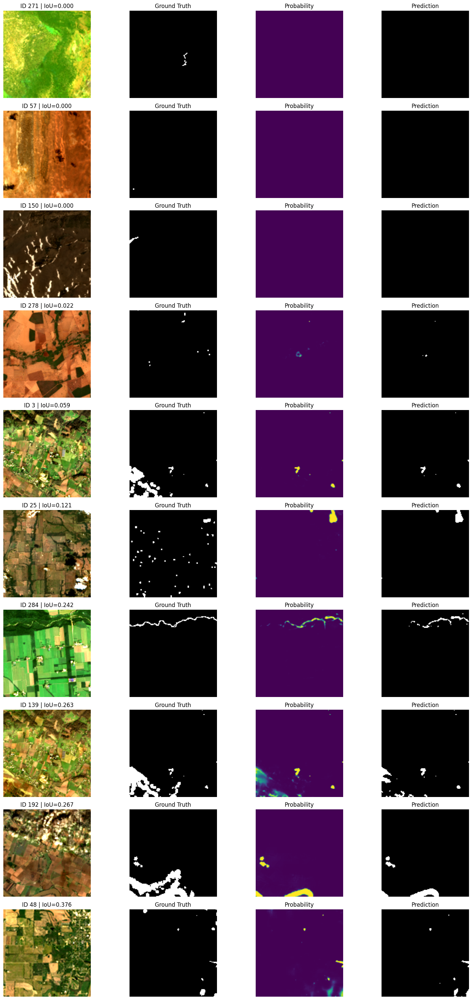

,Sample_ID,V2_Split,In_Worst10
0,76,Validation,False
1,293,Validation,False


In [117]:
final_runs=v2_results_df_all[(v2_results_df_all.Architecture==FINAL_ARCHITECTURE_V2)&(v2_results_df_all.Experiment==FINAL_EXPERIMENT_V2)].copy()
median_val=final_runs.Val_Global_IoU.median(); analysis_row=final_runs.iloc[(final_runs.Val_Global_IoU-median_val).abs().argsort().iloc[0]]; ANALYSIS_SEED_V2=int(analysis_row.Seed)
_,_,_,_,val_loader_analysis,_=create_v2_loaders(FINAL_EXPERIMENT_V2,ANALYSIS_SEED_V2,16); analysis_model=load_v2_model_from_result(analysis_row)
th_match=postprocess_df[(postprocess_df.Architecture==FINAL_ARCHITECTURE_V2)&(postprocess_df.Experiment==FINAL_EXPERIMENT_V2)&(postprocess_df.Seed==ANALYSIS_SEED_V2)]; ANALYSIS_THRESHOLD_V2=float(th_match.iloc[0].Threshold) if len(th_match) else 0.5
analysis_metrics_v2,per_image_val_v2=evaluate_loader_v2(analysis_model,val_loader_analysis,device,ANALYSIS_THRESHOLD_V2,True); worst10_v2=per_image_val_v2.nsmallest(10,"IoU").reset_index(drop=True)
print("Val global IoU:",f"{analysis_metrics_v2['iou']:.4f}","Mean per-image IoU:",f"{analysis_metrics_v2['mean_per_image_iou']:.4f}")
display(worst10_v2.round(4))

fig,axes=plt.subplots(len(worst10_v2),4,figsize=(16,3.0*len(worst10_v2)))
for r,row in worst10_v2.iterrows():
    sid=str(row.Sample_ID); raw=RAW_IMAGE_CACHE_V2[sid]; gt=MASK_CACHE_V2[sid]; rgb0=np.stack([raw[3],raw[2],raw[1]],-1); lo=np.percentile(rgb0,2); hi=np.percentile(rgb0,98); rgb=np.clip((rgb0-lo)/(hi-lo+1e-6),0,1)
    feat=build_experiment_features_v2(raw,FINAL_EXPERIMENT_V2,preprocessing_stats_v2); x=torch.from_numpy(feat).unsqueeze(0).float().to(device)
    with torch.no_grad(): prob=predict_probabilities_v2(analysis_model,x,True)[0,0].cpu().numpy()
    pred=prob>=ANALYSIS_THRESHOLD_V2
    axes[r,0].imshow(rgb); axes[r,0].set_title(f"ID {sid} | IoU={row.IoU:.3f}"); axes[r,1].imshow(gt,cmap="gray",vmin=0,vmax=1); axes[r,1].set_title("Ground Truth"); axes[r,2].imshow(prob,cmap="viridis",vmin=0,vmax=1); axes[r,2].set_title("Probability"); axes[r,3].imshow(pred,cmap="gray",vmin=0,vmax=1); axes[r,3].set_title("Prediction")
    for c in range(4): axes[r,c].axis("off")
plt.tight_layout(); plt.show()

split_lookup_v2={}
for name,df_ in [("Train",train_v2_df),("Validation",val_v2_df),("Test",test_v2_df)]:
    for sid in df_.Sample_ID.astype(str): split_lookup_v2[sid]=name
display(pd.DataFrame([{"Sample_ID":sid,"V2_Split":split_lookup_v2.get(sid,"Unknown"),"In_Worst10":sid in set(worst10_v2.Sample_ID.astype(str))} for sid in ["76","293"]]))


# 24. Dynamic Final Reporting

Nothing below is hard-coded. Use V2 mean ± std, global IoU, mean per-image IoU, shortcut limitations, spatial-leakage uncertainty, and possible label-noise/temporal-mismatch language in the README.


In [118]:
# 24.1 Dynamic Final Summary from Held-out Test
bench=postprocess_summary[(postprocess_summary.Architecture=="UNetBN")&(postprocess_summary.Experiment=="benchmark12")].iloc[0]
fin=postprocess_summary[(postprocess_summary.Architecture==FINAL_ARCHITECTURE_V2)&(postprocess_summary.Experiment==FINAL_EXPERIMENT_V2)].iloc[0]
final_reporting_df=pd.DataFrame([
{"Role":"Required 12-channel benchmark","Architecture":"UNetBN","Experiment":"benchmark12","Seeds":int(bench.Seeds),"Test base IoU mean":bench.Test_Base_IoU_Mean,"Test base IoU std":bench.Test_Base_IoU_Std,"Test TTA IoU mean":bench.Test_TTA_IoU_Mean,"Test TTA IoU std":bench.Test_TTA_IoU_Std,"Test TTA F1 mean":bench.Test_TTA_F1_Mean,"Test mean-image IoU":bench.Test_TTA_MeanImageIoU_Mean},
{"Role":"Selected final engineered model","Architecture":FINAL_ARCHITECTURE_V2,"Experiment":FINAL_EXPERIMENT_V2,"Seeds":int(fin.Seeds),"Test base IoU mean":fin.Test_Base_IoU_Mean,"Test base IoU std":fin.Test_Base_IoU_Std,"Test TTA IoU mean":fin.Test_TTA_IoU_Mean,"Test TTA IoU std":fin.Test_TTA_IoU_Std,"Test TTA F1 mean":fin.Test_TTA_F1_Mean,"Test mean-image IoU":fin.Test_TTA_MeanImageIoU_Mean}])
display(final_reporting_df.round(4))
final_seed=postprocess_df[(postprocess_df.Architecture==FINAL_ARCHITECTURE_V2)&(postprocess_df.Experiment==FINAL_EXPERIMENT_V2)][["Seed","Test_TTA_IoU"]].rename(columns={"Test_TTA_IoU":"Final"})
bench_seed=postprocess_df[(postprocess_df.Architecture=="UNetBN")&(postprocess_df.Experiment=="benchmark12")][["Seed","Test_TTA_IoU"]].rename(columns={"Test_TTA_IoU":"Benchmark"})
paired=final_seed.merge(bench_seed,on="Seed"); paired["Delta_IoU"]=paired.Final-paired.Benchmark; display(paired.round(4))
print("Mean paired TTA Test IoU delta:",f"{paired.Delta_IoU.mean():+.4f}","| positive all seeds:",bool((paired.Delta_IoU>0).all()))


,Role,Architecture,Experiment,Seeds,Test base IoU mean,Test base IoU std,Test TTA IoU mean,Test TTA IoU std,Test TTA F1 mean,Test mean-image IoU
0,Required 12-channel benchmark,UNetBN,benchmark12,3,0.6845,0.0055,0.6851,0.0064,0.8131,0.6011
1,Selected final engineered model,ResUNetBN,E4,3,0.7405,0.0005,0.7413,0.0036,0.8514,0.6565


,Seed,Final,Benchmark,Delta_IoU
0,42,0.7452,0.6793,0.0659
1,123,0.7405,0.6839,0.0566
2,2026,0.7381,0.6920,0.0461


Mean paired TTA Test IoU delta: +0.0562 | positive all seeds: True


### README-ready notes

Use V2 rather than V1 single-seed numbers. Say E1 **suggests** a benefit only if the three-seed pattern supports it. Report mean ± std, global IoU and mean per-image IoU. Keep the QA/WorldCover/Water Occurrence shortcut audit. State that validation handles checkpoint/config/threshold selection while test is held out. Keep spatial leakage as unresolved without source-scene metadata, and label noise / temporal mismatch as a possible limitation rather than a confirmed fact. Save `stats.json`, `split_v2.csv`, result CSVs and checkpoints. Suggested repo layout: `notebooks/`, `src/`, `results/`, `README.md`.
